# 05. 기상 × 카드 결합 (메인 분석)

## 이 노트북이 하는 일
폭염과 호우가 **카드 매출을 얼마나 바꾸는지(A. 수준 차이)**, 그리고 **충격 뒤에 어떻게 돌아오는지(B. 이벤트 전후 추이)** 를 본다.
02번에서 알아낸 달력 효과(요일, 공휴일, 추석)를 회귀로 먼저 걷어내고, 남은 부분(잔차)에서 날씨 효과를 찾는다.
이 프로젝트의 질문 "기상 충격이 매출을 얼마나 떨어뜨리고 어떻게 회복되는가"에 직접 답하는 노트북이다.

## 답해야 할 질문
1. 달력 효과를 걷어내면 폭염일, 열대야, 호우일의 매출은 평소보다 몇 % 다른가? 업종그룹마다 다른가?
2. 결제가 0건인 날이 잦은 업종은 효과가 얼마나 불안정한가?
3. 효과는 누구에게, 언제 나타나는가? (연령 -> 성별 -> 시간대 순서로 쪼개기)
4. 사람이 안 온 것인가, 와서 덜 쓴 것인가? 외지인이 먼저 빠지는가?
5. 충격 뒤 매출은 바로 돌아오는가, 늦게 돌아오는가, 안 돌아오는가? 미뤄진 소비가 몰리는가(pent-up)?
6. 지하철 승하차(유동)와 매출(소비)은 같이 움직이는가? 강남과 춘천은 같은 방향인가?

## 입력과 출력
| 입력 (`notebooks/preprocessed/`) | 만든 노트북 | 출력 |
|---|---|---|
| `card1.parquet`, `calendar.parquet`, `industry_map.csv` | 01 | 그래프와 결과 표 (노트북 안) |
| `card2_outsider_daily.parquet` | 02 (9-6) | 저장하는 파일 없음 |
| `subway_region_daily.parquet` | 03 | |
| `wx_region_daily.parquet`, `wx_region_slot.parquet`, `wx_events.parquet` | 04 | |

> 먼저 실행할 노트북: **01 -> 02 -> 03 -> 04 -> 07(탐색 Q1~Q9)** 을 끝낸 뒤 이 노트북을 연다.
> 07번에서 정한 폭염 임계값(Q3)과 이벤트 창 길이(Q7)를 0-3에 옮겨 적고 시작한다. 아직 안 정했으면 0-3의 잠정값(33℃, -3일 ~ +7일)으로 먼저 돌려본다.

## 이 노트북의 규칙
- 코드 셀에는 **TODO 주석**만 적혀 있다. 주석을 읽고 그 아래에 코드를 채워 넣는다.
- TODO마다 **확인용 참고값**이 있다. 직접 짠 코드의 결과가 이 값과 비슷하면 맞게 한 것이다. (01~04번 결과로 미리 계산한 값. 0-3의 잠정값 기준)
- 각 장 끝의 **정리** 칸(본 것 / 나온 것 / 시사점)은 그래프를 본 뒤 한 줄씩 채운다.
- 금액은 **억 원** 단위로 보면 읽기 편한다. (`amount / 1e8`)
- 회귀 계수는 로그 매출에 대한 값이라 **% 효과 = (exp(계수) - 1) × 100** 으로 바꿔 읽는다. 예: 계수 -0.10 -> 약 -9.5%
- 표를 볼 때는 `print(표)` 대신 **`display(표)`** 를 쓴다. 칸이 나뉜 표로 나와서 보기 편한다. 열 하나짜리(Series)는 `display(s.to_frame())`, 셀 마지막 줄에 표 이름만 적어도 표로 나온다.

## 결과 요약
1. **폭염은 매출을 떨어뜨리지 않는다.** 달력을 통제하면 폭염일 매출은 강남 +2.4%, 춘천 +5.1%로 오히려 약간 높고 신뢰구간이 0을 걸친다. 더운 날 카페, 편의점, 대형유통이 오르고 야외 업종이 빠지는 **수요 이동**이 일어날 뿐이다.
2. **매출을 확실히 떨어뜨리는 것은 춘천의 호우다.** 호우일 춘천 지역 합계 -8.7% ~ -10.2%. 강남은 0에 가깝다(원래 -11%로 보이던 강남 호우 효과는 추석 당일 하루 때문이었다).
3. **감소의 경로는 방문이다.** 춘천 호우 -0.091 = 건수 -0.100 + 객단가 +0.009. 외지인(-18.7%)이 현지인(-6.4%)보다 3배 크게 빠지고, 지하철 유동은 카드의 약 2배(-15.8%) 빠진다.
4. **회복은 하루, 손실은 영구다.** 호우 다음 날 매출은 -0.7%로 돌아오지만 종료 후 1주 평균은 0 근처(p 0.47)로 반등이 없다. 비 온 날 못 쓴 돈은 돌아오지 않는 **순손실**이다.
5. **늦게 돌아오는 업종은 외지인 의존 업종이다.** 춘천 호우 기준 즉시회복 10개, 지연회복 3개(생활/취미용품, 숙박/여행, 패션/뷰티), 미회복 1개(여가/오락).

## 0. 준비

### 0-1. 라이브러리 불러오기와 그래프 기본 설정

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import statsmodels.formula.api as smf   # 'y ~ x1 + x2' 같은 식(formula)으로 회귀를 돌리는 도구
from scipy import stats                 # 7-4의 t검정(평균이 0과 다른가)

sns.set_theme(style='whitegrid')
plt.rc('font', family='Malgun Gothic')
plt.rc('axes', unicode_minus=False)
plt.rc('figure', figsize=(12, 4), dpi=110)

REGIONS = ['강남', '춘천']
REGION_COLOR = {'강남': '#1f77b4', '춘천': '#ff7f0e'}

# 이 노트북은 0.01 단위(로그 차이, 비율)를 많이 보므로 소수 셋째 자리까지 보여 준다.
pd.set_option('display.float_format', '{:,.3f}'.format)
print('준비 완료')

준비 완료


### 0-2. 경로 설정과 데이터 불러오기

In [2]:
# 01번 노트북과 같은 방식으로 프로젝트 맨 위 폴더를 찾는다.
ROOT = Path.cwd()
while not (ROOT / 'dataset').exists():
    if ROOT.parent == ROOT:
        raise FileNotFoundError('dataset 폴더를 찾을 수 없다. 노트북 위치를 확인한다.')
    ROOT = ROOT.parent
OUT = ROOT / 'notebooks' / 'preprocessed'

card1        = pd.read_parquet(OUT / 'card1.parquet')                # 01번: 날짜 x 시간대 x 지역 x 업종 x 성별 x 연령
calendar     = pd.read_parquet(OUT / 'calendar.parquet')             # 01번: 날짜별 요일, 공휴일
industry_map = pd.read_csv(OUT / 'industry_map.csv')                 # 01번: 업종 -> 업종그룹, 분석 대상 여부
wx           = pd.read_parquet(OUT / 'wx_region_daily.parquet')      # 04번: 날짜 x 지역 일별 날씨
wx_slot      = pd.read_parquet(OUT / 'wx_region_slot.parquet')       # 04번: 날짜 x 지역 x 시간대 날씨
events       = pd.read_parquet(OUT / 'wx_events.parquet')            # 04번: 폭염, 호우 연속 구간 목록
subway_daily = pd.read_parquet(OUT / 'subway_region_daily.parquet')  # 03번: 지역별 일별 승하차
outsider     = pd.read_parquet(OUT / 'card2_outsider_daily.parquet') # 02번: 외지인 금액

for name, df in [('card1', card1), ('calendar', calendar), ('industry_map', industry_map),
                 ('wx', wx), ('wx_slot', wx_slot), ('events', events),
                 ('subway_daily', subway_daily), ('outsider', outsider)]:
    print(f'{name:13s} {df.shape[0]:>9,}행 x {df.shape[1]:2d}열')

display(events.groupby(['event', 'region']).size().rename('구간 수').to_frame().T)

# 04번에서 서울 ASOS(108) 값으로 바꿔 넣은 날
display(wx.loc[wx['filled_from_108'], ['date', 'region', 'tmax', 'rain']])

card1         1,663,909행 x 11열
calendar            184행 x  9열
industry_map         91행 x  4열
wx                  368행 x 20열
wx_slot           1,472행 x  7열
events               43행 x  7열
subway_daily      2,678행 x  5열
outsider          5,152행 x  6열


event  heat33     rain30    
region     강남  춘천     강남  춘천
구간 수       10  10      9  14

,date,region,tmax,rain
71,2025-09-10,강남,31.500,0.000
72,2025-09-11,강남,31.700,0.000
74,2025-09-13,강남,27.000,63.700
109,2025-10-18,강남,18.000,11.200


### 0-3. 앞 노트북에서 가져온 결정
02번 10-1 표와 07번 탐색에서 정한 내용을 **변수 하나씩** 으로 옮겨 둔다. 아래 코드는 모두 이 변수를 쓴다.
아직 정하지 않은 항목은 아래 **잠정값** 으로 두고, 나중에 바꾸면 이 셀만 고치고 전체를 다시 실행한다.

> 이벤트 창: 기획 문서는 -7일 ~ +14일이었지만, 04번과 07번에서 확인한 대로 2025년 여름 폭염 구간은 간격이 짧아서(중앙값 강남 2일, 춘천 3일)
> 이 창이 깨끗한 폭염 구간은 하나도 없다. 그래서 잠정값은 계산이 되는 (-3, 7) 로 두고, 6장에서 창 길이별로 다시 센다.

| 변수 | 내용 | 잠정값 | 어디서 정했나 |
|---|---|---|---|
| (is_target) | 분석 대상 업종 | 01번 그대로 | 02번 5-5 |
| `PRIORITY_GROUPS` | 날씨 분석 1순위 업종그룹 (규모 크고 안정적) | 음식점, 카페, 편의점, 식료품 | 02번 5-4 |
| `CAUTION_GROUPS` | 결제가 0건인 날이 잦아 조심할 업종그룹 | 주점/유흥, 여가/오락 | 02번 2-3 |
| `INCLUDE_CORP` | 법인 결제 포함 여부 | False (개인만) | 02번 8장 |
| `TIME_TYPE` | 업종그룹별 시간대 유형 | 02번 6-3 예시 규칙 결과 | 02번 6-3 |
| `AGE_GROUP` | 연령 묶기 | 60대 이상을 하나로 | 02번 7-3 |
| `LOCAL` | 외지인 정의 (현지 시도) | 강남: 서울, 춘천: 강원 | 02번 9-2 |
| `CAL_FORMULA` | 달력 통제 식 | 요일 + 공휴일 + 월 + 추석 연휴 + 추석 3일 (월말은 선택) | 02번 4장, 07번, 이 노트북 2-4 |
| `THRESH` | 폭염, 열대야, 호우 임계값 | 33℃, 25℃, 30mm | 07번 Q3, Q4 |
| `WINDOW` | 이벤트 창 (시작일 기준 며칠 전 ~ 며칠 후) | (-3, 7) | 07번 Q7, 이 노트북 7-2 |
| `RECOVERY_BAND` | "평소로 돌아왔다"고 볼 폭 (로그 차이) | 0.03 (약 3%) | 이 노트북 8-1 |

In [3]:
# --- 업종그룹 목록 -------------------------------------------------------
PRIORITY_GROUPS = ['음식점', '카페', '편의점', '식료품']   # 02번 5-4: 규모가 크고 안정적
CAUTION_GROUPS  = ['주점/유흥', '여가/오락']              # 02번 2-3: 결제가 0건인 날이 잦음
INCLUDE_CORP    = False                                  # 02번 8장: 법인 결제는 빼고 본다

# --- 02번 6-3의 시간대 유형 ----------------------------------------------
TIME_TYPE = {'음식점': '밤형', '주점/유흥': '밤형', '여가/오락': '밤형',
             '의료': '오전형', '교통/차량': '오전형',
             '패션/뷰티': '오후형', '미용/생활서비스': '오후형', '생활/취미용품': '오후형',
             '카페': '종일형', '편의점': '종일형', '식료품': '종일형', '대형유통': '종일형',
             '숙박/여행': '종일형', '스포츠시설': '종일형'}

# --- 02번 7-3의 연령 묶기 (60대 이상은 하나로) ---------------------------
AGE_GROUP = {'10대': '10대', '20대': '20대', '30대': '30대', '40대': '40대', '50대': '50대',
             '60대': '60대 이상', '70대': '60대 이상', '80대': '60대 이상', '90대': '60대 이상'}

# --- 02번 9-2의 외지인 정의 (현지 시도) ----------------------------------
LOCAL = {'강남': '서울', '춘천': '강원'}

# --- 달력 통제 식 --------------------------------------------------------
# C(열) = 그 열의 값마다 더미(0/1 열)를 만들라는 뜻. C(dow) -> 요일 7개 중 6개 더미(월요일이 기준)
# 월말 통제를 넣기로 하면 끝에 ' + is_month_end' 를 붙인다 (2-4에서 결정).
CAL_FORMULA = 'C(dow) + is_holiday + C(month) + is_chuseok_break + C(chuseok_day)'

# --- 날씨 기준과 이벤트 창 ----------------------------------------------
THRESH        = {'heat': 33, 'tropical': 25, 'rain': 30}   # 07번 Q3, Q4
WINDOW        = (-3, 7)                                    # 07번 Q7: (-7, 14)로는 깨끗한 폭염 구간이 0개
RECOVERY_BAND = 0.03                                       # "평소로 돌아왔다"고 볼 폭 (로그 차이, 약 3%)

for k, v in [('PRIORITY_GROUPS', PRIORITY_GROUPS), ('CAUTION_GROUPS', CAUTION_GROUPS),
             ('INCLUDE_CORP', INCLUDE_CORP), ('CAL_FORMULA', CAL_FORMULA),
             ('THRESH', THRESH), ('WINDOW', WINDOW), ('RECOVERY_BAND', RECOVERY_BAND)]:
    print(f'{k:16s} = {v}')
print(f'업종그룹 {len(TIME_TYPE)}개, 연령 묶은 뒤 = {sorted(set(AGE_GROUP.values()))}')

PRIORITY_GROUPS  = ['음식점', '카페', '편의점', '식료품']
CAUTION_GROUPS   = ['주점/유흥', '여가/오락']
INCLUDE_CORP     = False
CAL_FORMULA      = C(dow) + is_holiday + C(month) + is_chuseok_break + C(chuseok_day)
THRESH           = {'heat': 33, 'tropical': 25, 'rain': 30}
WINDOW           = (-3, 7)
RECOVERY_BAND    = 0.03
업종그룹 14개, 연령 묶은 뒤 = ['10대', '20대', '30대', '40대', '50대', '60대 이상']


### 0-4. 분석 기본 표와 추석 3일 처리

In [4]:
# 1) 분석 대상 행만 남기기
base1 = card1[card1['is_target']].copy()
if not INCLUDE_CORP:
    base1 = base1[base1['sex'].ne('법인')]
print(f'base1 {len(base1):,}행, 금액 합계 {base1["amount"].sum() / 1e12:.2f}조 원')

# 2) 추석 3일(전날 1, 당일 2, 다음날 3)과 월말 열 만들기
CORE = {pd.Timestamp('2025-10-05'): 1, pd.Timestamp('2025-10-06'): 2, pd.Timestamp('2025-10-07'): 3}
calendar['chuseok_day'] = calendar['date'].map(CORE).fillna(0).astype(int)
calendar['is_month_end'] = calendar['date'].dt.day >= 25   # 2-4에서 비교용
print(f'calendar 열 {calendar.shape[1]}개')

# 3) 추석 3일에 걸린 호우 표시는 끄기
#    강남 10/6(추석 당일)이 하필 호우일이라, 매출이 낮은 이유가 추석인지 비인지 나눌 방법이 없다.
끈날 = wx.loc[wx['date'].isin(CORE) & wx['rain30'], ['date', 'region', 'rain']]
display(끈날)
wx.loc[wx['date'].isin(CORE), 'rain30'] = False
events = events[~(events['event'].eq('rain30') & events['start'].isin(CORE))].reset_index(drop=True)
print(f'events {len(events)}행')
display(events.groupby(['event', 'region']).size().rename('구간 수').to_frame().T)

# 4) 임계값이 04번 기본값(33, 25, 30)과 다르면 열을 다시 만든다
if THRESH['heat'] != 33:
    wx['heat33'] = wx['tmax'] >= THRESH['heat']
if THRESH['tropical'] != 25:
    wx['tropical'] = wx['tmin'] >= THRESH['tropical']
if THRESH['rain'] != 30:
    wx['rain30'] = wx['rain'] >= THRESH['rain']

base1 1,285,449행, 금액 합계 11.15조 원
calendar 열 11개


,date,region,rain
97,2025-10-06,강남,44.500


events 42행


event  heat33     rain30    
region     강남  춘천     강남  춘천
구간 수       10  10      8  14

## 1. 분석 패널 만들기
**패널** = 같은 대상(여기서는 지역 × 업종 칸)을 날마다 관찰한 표이다. 184일 × 칸 수 만큼 행이 생길다.
01번 3-2에서 결제가 없던 날을 0으로 채워 두었으므로, **패널은 한 버전만** 만든다.

### 1-1. 업종 패널

In [5]:
# 한 행 = 날짜 x 지역 x 업종 하나. 시간대, 성별, 연령은 모두 더해서 없앤다.
panel = base1.groupby(['date', 'region', 'industry_group', 'industry'],
                      as_index=False, observed=True).agg(amount=('amount', 'sum'),
                                                         cnt=('cnt', 'sum'))

# 객단가 = 결제 한 건당 평균 금액. cnt가 0인 날(결제가 없던 날)은 나눌 수 없으므로 NaN으로 둔다.
panel['ticket'] = panel['amount'] / panel['cnt'].replace(0, np.nan)

print(f'panel {len(panel):,}행')
display(panel.groupby('region')['industry'].nunique().rename('업종 수').to_frame().T)
display(panel.groupby('region')['ticket'].median().rename('객단가 중앙값(원)').to_frame().T)
print(f'금액이 0인 칸(그날 그 업종에 결제가 하나도 없었음): {(panel["amount"] == 0).sum():,}개')

panel 24,462행


region,강남,춘천
업종 수,67,66


region,강남,춘천
객단가 중앙값(원),"52,513.841","39,965.609"


금액이 0인 칸(그날 그 업종에 결제가 하나도 없었음): 504개


### 1-2. 날씨와 달력 붙이기

In [6]:
def add_wx_cal(p):
    # 달력과 날씨를 붙이고, 로그 매출 y를 만든다.
    # 로그를 쓰면 계수가 "몇 %"로 읽히고, 큰 업종과 작은 업종을 같은 눈금으로 볼 수 있다.
    p = p.merge(calendar, on='date').merge(wx, on=['date', 'region'])
    # 금액이 0인 칸은 log(0)이 정의되지 않으므로 NaN으로 둔다 (회귀에서 자동으로 빠진다).
    p['y'] = np.log(p['amount'].where(p['amount'] > 0))
    return p


전 = len(panel)
panel = add_wx_cal(panel)
print(f'붙이기 전 {전:,}행 -> 뒤 {len(panel):,}행, 열 {panel.shape[1]}개')
print(f'y가 NaN인 행(금액 0): {panel["y"].isna().sum():,}개')
print(f'y, ticket 말고 빈 값이 있는 칸 수: {panel.drop(columns=["y", "ticket"]).isna().sum().sum():,}개')

붙이기 전 24,462행 -> 뒤 24,462행, 열 36개
y가 NaN인 행(금액 0): 504개
y, ticket 말고 빈 값이 있는 칸 수: 0개


### 1-3. 칸마다 며칠치가 있는가

In [7]:
# 01번 3-2에서 관측 구간(첫 관측일 ~ 마지막 관측일)을 0으로 채웠으므로,
# 184일이 안 되는 칸은 '그 업종이 도중에 생겼거나 사라진' 경우뿐이다.
일수 = panel.groupby(['region', 'industry'], observed=True)['date'].agg(
    일수='nunique', 첫날='min', 마지막날='max').reset_index()
모자란칸 = 일수[일수['일수'] != 184]
print(f'184일이 아닌 칸 {len(모자란칸)}개 / 전체 {len(일수)}개')
display(모자란칸)

# 이 칸들이 전체 금액에서 차지하는 비중
작은칸 = panel.merge(모자란칸[['region', 'industry']], on=['region', 'industry'])
print(f'이 칸들의 금액 비중: {작은칸["amount"].sum() / panel["amount"].sum() * 100:.3f}%')
print('-> 비중이 매우 작고 업종 고정효과가 각자 평균을 빼 주므로, 빼지 않고 그대로 둔다.')

184일이 아닌 칸 2개 / 전체 133개


,region,industry,일수,첫날,마지막날
87,춘천,쇼핑몰,182,2025-07-01,2025-12-29
99,춘천,여행사/항공사,176,2025-07-02,2025-12-24


이 칸들의 금액 비중: 0.001%
-> 비중이 매우 작고 업종 고정효과가 각자 평균을 빼 주므로, 빼지 않고 그대로 둔다.


### 1-4. 업종그룹 패널

In [8]:
# 업종 67개는 결과를 읽기에 너무 많다. 업종그룹 14개로 한 번 더 묶은 표를 만든다.
group = base1.groupby(['date', 'region', 'industry_group'],
                      as_index=False, observed=True).agg(amount=('amount', 'sum'),
                                                         cnt=('cnt', 'sum'))
group['ticket'] = group['amount'] / group['cnt'].replace(0, np.nan)
group = add_wx_cal(group)

GROUPS = sorted(group['industry_group'].unique())
print(f'group {len(group):,}행 = {group["date"].nunique()}일 x {group["region"].nunique()}지역 x {len(GROUPS)}그룹')
print(f'금액이 0인 칸: {(group["amount"] == 0).sum()}개')
print(GROUPS)

group 5,152행 = 184일 x 2지역 x 14그룹
금액이 0인 칸: 0개
['교통/차량', '대형유통', '미용/생활서비스', '생활/취미용품', '숙박/여행', '스포츠시설', '식료품', '여가/오락', '음식점', '의료', '주점/유흥', '카페', '패션/뷰티', '편의점']


### 1장 정리
- **본 것**: 개인 결제만 남긴 base1 128만 행을 날짜 x 지역 x 업종 패널(24,462행)과 업종그룹 패널(5,152행)로 접었다.
- **나온 것**: 01번에서 0을 채워 두어 184일이 안 되는 칸은 2개(춘천 쇼핑몰, 여행사/항공사)뿐이고 금액 비중은 0.001%다. 다만 금액이 0인 칸이 504개(2.1%) 있어 로그를 못 쓰고 회귀에서 빠진다.
- **시사점**: 균형 패널을 따로 만들 필요가 없어졌다. 대신 0인 날이 잦은 업종(`CAUTION_GROUPS`)은 회귀에 들어가는 날 수가 줄어든다는 점을 결과를 읽을 때 기억한다.

## 2. 기준선 만들기 (고정효과 회귀)
"폭염일 매출이 평소보다 낮은가"를 보려면 먼저 **"평소라면 얼마였을까" (기준선)** 가 있어야 한다.
요일, 공휴일, 월, 추석을 한꺼번에 통제하는 회귀를 돌리고, 실제 값과 기준선의 차이(**잔차**)를 날씨 분석의 재료로 쓴다.

**고정효과(fixed effect)란?** 칸(여기서는 업종)마다 자기 평균을 빼는 것이다.
한식과 면세점은 원래 매출 규모가 수십 배 다르지만, 각자 평균을 빼면 "그 업종치고 오늘 많이 팔렸나 적게 팔렸나"만 남는다.
회귀식에 `C(industry)` 를 넣으면 이 작업을 자동으로 해 준다.

### 2-1. 고정효과를 손으로 해 보기

강남: 분산 3.40 -> 0.40  (업종 차이가 로그 매출 변동의 88%를 설명)
춘천: 분산 3.72 -> 0.55  (업종 차이가 로그 매출 변동의 85%를 설명)


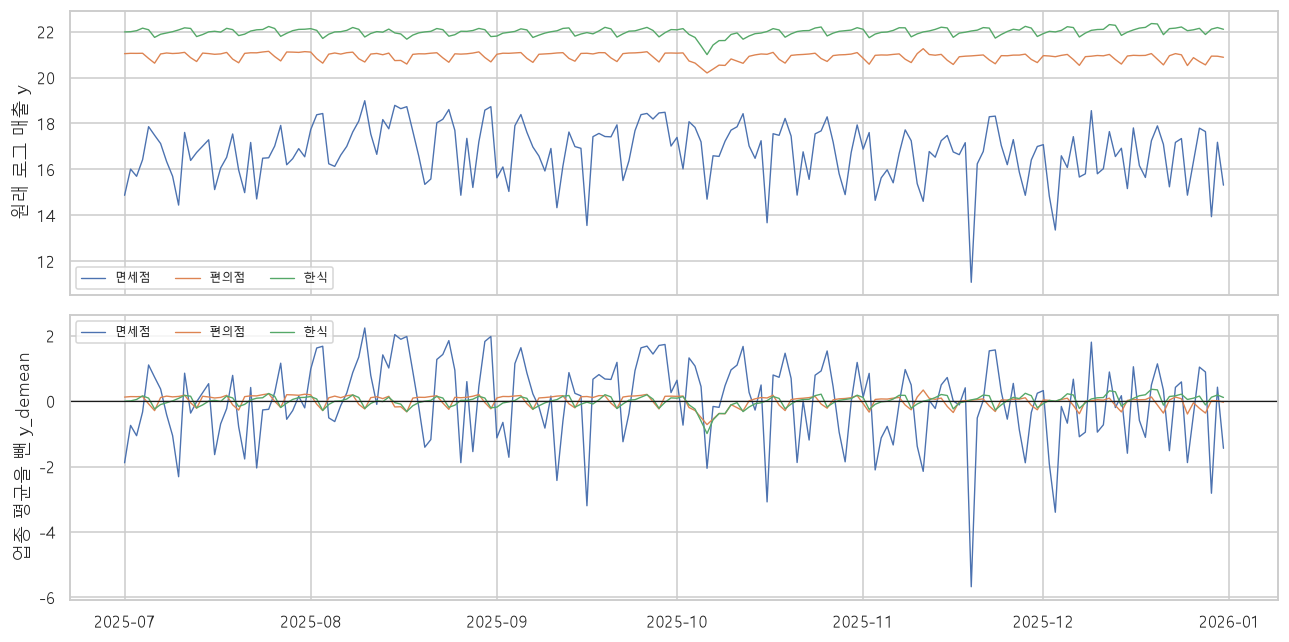

-> 원래는 업종끼리 층이 완전히 나뉘어 있지만, 평균을 빼면 모두 0 근처에서 같이 흔들린다.
   날마다 달라지는 부분은 전체 변동의 10% 남짓이다. 날씨 효과는 이 작은 부분 안에서 찾는다.


In [9]:
# 업종마다 평균을 빼면(고정효과) 로그 매출의 흩어짐이 얼마나 줄어드는지 눈으로 본다.
for r in REGIONS:
    q = panel[panel['region'].eq(r) & panel['y'].notna()]
    원래 = q['y'].var()
    뺀값 = q['y'] - q.groupby('industry', observed=True)['y'].transform('mean')
    print(f'{r}: 분산 {원래:.2f} -> {뺀값.var():.2f}  '
          f'(업종 차이가 로그 매출 변동의 {(1 - 뺀값.var() / 원래) * 100:.0f}%를 설명)')

# 업종 3개만 골라 원래 값과 평균을 뺀 값을 비교
보기 = ['한식', '편의점', '면세점']
q = panel[panel['region'].eq('강남') & panel['industry'].isin(보기) & panel['y'].notna()].copy()
q['y_demean'] = q['y'] - q.groupby('industry', observed=True)['y'].transform('mean')

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
for 이름, 열 in [('원래 로그 매출 y', 'y'), ('업종 평균을 뺀 y_demean', 'y_demean')]:
    ax = axes[0] if 열 == 'y' else axes[1]
    for ind, g in q.groupby('industry', observed=True):
        ax.plot(g['date'], g[열], lw=0.9, label=ind)
    ax.set(ylabel=이름)
    ax.legend(ncol=3, fontsize=8)
axes[1].axhline(0, color='k', lw=0.8)
plt.tight_layout(); plt.show()
print('-> 원래는 업종끼리 층이 완전히 나뉘어 있지만, 평균을 빼면 모두 0 근처에서 같이 흔들린다.')
print('   날마다 달라지는 부분은 전체 변동의 10% 남짓이다. 날씨 효과는 이 작은 부분 안에서 찾는다.')

### 2-2. 지역별 기준선 회귀

In [10]:
BASE = 'y ~ C(industry) + ' + CAL_FORMULA   # 날씨는 아직 넣지 않는다

models, 잔차들 = {}, []
for r in REGIONS:
    q = panel[panel['region'].eq(r) & panel['y'].notna()].copy()
    m = smf.ols(BASE, data=q).fit()        # ols = 오차 제곱합이 가장 작아지는 계수를 찾는 회귀
    models[r] = m
    q['resid'] = m.resid                   # 잔차 = 실제 - 기준선
    잔차들.append(q)
    print(f'{r}: R2 {m.rsquared:.3f}  (계수 {len(m.params)}개, 대부분 업종 고정효과)')

resid_full = pd.concat(잔차들, ignore_index=True)

# 달력 계수를 % 효과로 바꿔서 본다 (% 효과 = (exp(계수) - 1) x 100)
DOW_NAME = {0: '월', 1: '화', 2: '수', 3: '목', 4: '금', 5: '토', 6: '일'}
표 = {}
for r in REGIONS:
    e = (np.exp(models[r].params) - 1) * 100
    고른것 = {}
    for 이름, 값 in e.items():
        if 이름.startswith('C(dow)'):
            고른것[DOW_NAME[int(이름.split('T.')[1].rstrip(']'))] + '요일'] = 값
        elif 이름.startswith('is_holiday'):
            고른것['공휴일'] = 값
        elif 이름.startswith('is_chuseok_break'):
            고른것['추석 연휴'] = 값
        elif 이름.startswith('C(chuseok_day)'):
            고른것[{'1': '추석 전날', '2': '추석 당일', '3': '추석 다음날'}[이름.split('T.')[1].rstrip(']')]] = 값
    표[r] = 고른것
display(pd.DataFrame(표).round(1).rename_axis('달력 효과 (%)'))
print('-> 기준은 월요일, 평일, 추석이 아닌 날이다. 강남은 쉬는 날 크게 빠지고 춘천은 토요일이 가장 강하다.')

강남: R2 0.901  (계수 83개, 대부분 업종 고정효과)
춘천: R2 0.861  (계수 82개, 대부분 업종 고정효과)


,강남,춘천
달력 효과 (%),,
화요일,4.000,0.600
수요일,3.300,1.000
목요일,7.600,1.800
금요일,19.900,15.200
토요일,11.500,29.200
일요일,-38.100,-24.800
공휴일,-36.300,-2.600
추석 연휴,-8.000,-1.600
추석 전날,21.100,-6.500


-> 기준은 월요일, 평일, 추석이 아닌 날이다. 강남은 쉬는 날 크게 빠지고 춘천은 토요일이 가장 강하다.


### 2-3. 잔차 = 기준선 대비 차이

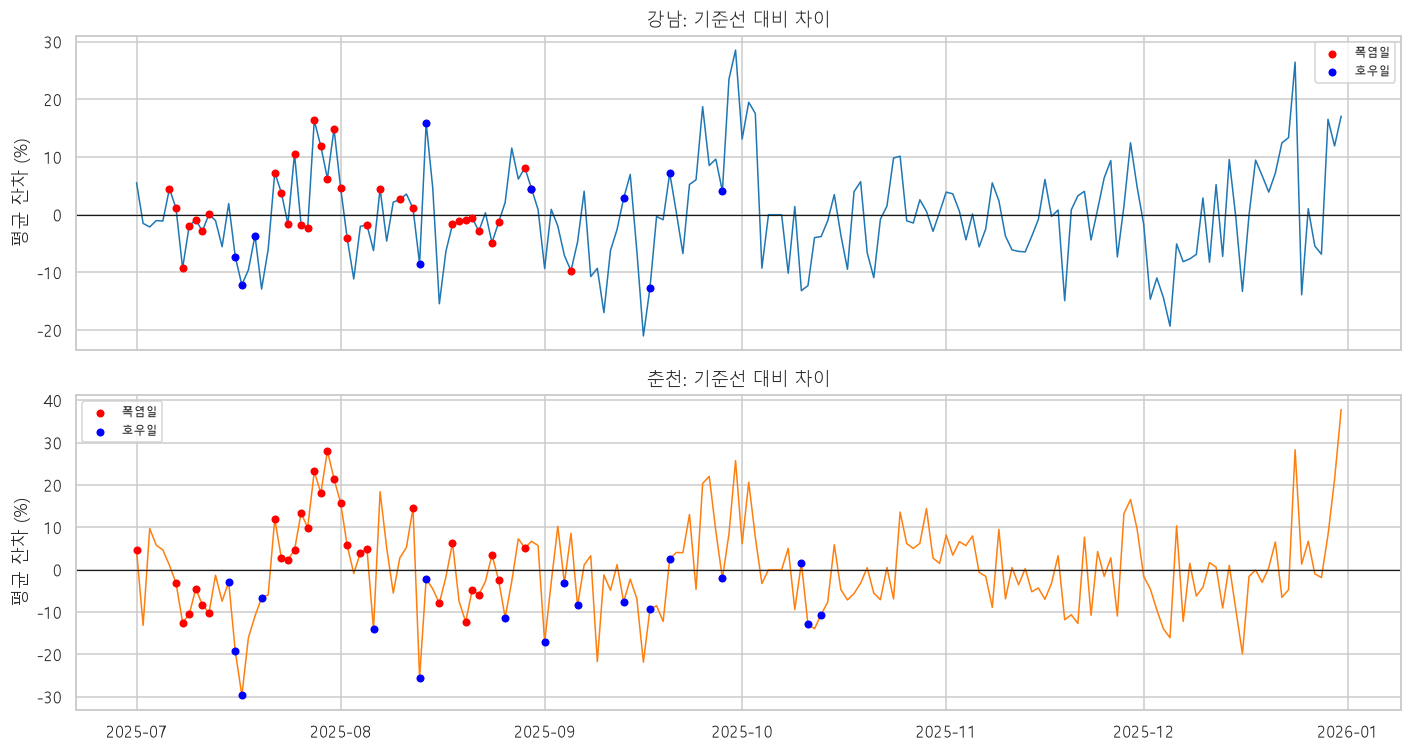

,폭염일,호우일,나머지 날
평균 잔차 (%),,,
강남,1.600,-1.000,-0.300
춘천,3.900,-9.900,0.400


강남 잔차가 가장 낮은 3일


,date,pct,tmax,rain,heat33,rain30
0,2025-09-16,-21.018,28.200,15.500,False,False
1,2025-12-05,-19.319,2.100,0.000,False,False
2,2025-09-10,-16.968,31.500,0.000,False,False


춘천 잔차가 가장 낮은 3일


,date,pct,tmax,rain,heat33,rain30
0,2025-07-17,-29.681,23.500,42.100,False,True
1,2025-08-13,-25.481,24.300,65.100,False,True
2,2025-09-16,-21.833,25.100,14.600,False,False


-> 춘천 7/17, 8/13은 둘 다 호우일이다. 02번 3-3의 "춘천 7/17 수수께끼"의 답.
-> 폭염일은 평소보다 오히려 약간 높다. 3장에서 회귀로 제대로 확인한다.


In [11]:
# 잔차(resid) = 실제 로그 매출 - 기준선. 0.05면 "달력으로 예상한 것보다 약 5% 많이 팔림"
일별 = (resid_full.groupby(['region', 'date'], observed=True)
        .agg(resid=('resid', 'mean'), heat33=('heat33', 'first'), rain30=('rain30', 'first'))
        .reset_index())
일별['pct'] = 일별['resid'] * 100

fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)
for ax, r in zip(axes, REGIONS):
    g = 일별[일별['region'].eq(r)]
    ax.plot(g['date'], g['pct'], color=REGION_COLOR[r], lw=1)
    ax.scatter(g.loc[g['heat33'], 'date'], g.loc[g['heat33'], 'pct'],
               color='red', s=18, zorder=3, label='폭염일')
    ax.scatter(g.loc[g['rain30'], 'date'], g.loc[g['rain30'], 'pct'],
               color='blue', s=18, zorder=3, label='호우일')
    ax.axhline(0, color='k', lw=0.8)
    ax.set(ylabel='평균 잔차 (%)', title=f'{r}: 기준선 대비 차이')
    ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

행 = []
for r in REGIONS:
    g = 일별[일별['region'].eq(r)]
    행.append({'지역': r,
               '폭염일': g.loc[g['heat33'], 'pct'].mean(),
               '호우일': g.loc[g['rain30'], 'pct'].mean(),
               '나머지 날': g.loc[~g['heat33'] & ~g['rain30'], 'pct'].mean()})
display(pd.DataFrame(행).set_index('지역').round(1).rename_axis('평균 잔차 (%)'))

for r in REGIONS:
    g = 일별[일별['region'].eq(r)].nsmallest(3, 'pct').merge(
        wx[['date', 'region', 'tmax', 'rain']], on=['date', 'region'])
    print(f'{r} 잔차가 가장 낮은 3일')
    display(g[['date', 'pct', 'tmax', 'rain', 'heat33', 'rain30']])
print('-> 춘천 7/17, 8/13은 둘 다 호우일이다. 02번 3-3의 "춘천 7/17 수수께끼"의 답.')
print('-> 폭염일은 평소보다 오히려 약간 높다. 3장에서 회귀로 제대로 확인한다.')

### 2-4. 달력 통제 다듬기 (추석 3일과 월말)

In [12]:
# 1) C(chuseok_day)를 뺀 식으로 다시 돌려 본다
없는식 = 'y ~ C(industry) + ' + CAL_FORMULA.replace(' + C(chuseok_day)', '')
행 = []
for r in REGIONS:
    q = panel[panel['region'].eq(r) & panel['y'].notna()].copy()
    q['넣은식'] = models[r].resid
    q['뺀식'] = smf.ols(없는식, data=q).fit().resid
    추석 = q[q['date'].isin(CORE)].groupby('date')[['넣은식', '뺀식']].mean() * 100
    추석.insert(0, '지역', r)
    행.append(추석)
비교 = pd.concat(행).reset_index().set_index(['지역', 'date'])
display(비교.round(1).rename_axis(['지역', '날짜']).rename(columns=lambda c: c + ' 잔차 (%)'))
print('-> 추석 연휴 7일을 한 덩어리로만 통제하면 연휴 안의 큰 차이(전날 장보기, 당일 휴무)를 못 잡는다.')
print('-> 게다가 강남 10/6은 원래 호우일이라, 그대로 두면 강남 호우 효과가 부풀려 보인다 (0-4에서 끔).')

# 2) 월말(25일 이후) 확인
행 = []
for r in REGIONS:
    g = 일별[일별['region'].eq(r)].copy()
    g['월말'] = g['date'].dt.day >= 25
    행.append({'지역': r,
               '25일 이후': g.loc[g['월말'], 'pct'].mean(),
               '그 외': g.loc[~g['월말'], 'pct'].mean()})
월말표 = pd.DataFrame(행).set_index('지역')
월말표['차이(%p)'] = 월말표['25일 이후'] - 월말표['그 외']
display(월말표.round(1).rename_axis('월말 평균 잔차 (%)'))
print('-> 월 더미까지 넣은 기준선인데도 25일 이후가 10%p 가까이 높다. 월급날, 카드 결제일과 관련된 것으로 보인다.')
print('-> 이 노트북에서 찾는 어떤 날씨 효과보다 큰 값이다. 3-2에서 월말 더미를 넣으면 폭염 계수가 얼마나 바뀌는지 본다.')

넣은식 잔차 (%)  뺀식 잔차 (%)
지역 날짜                               
강남 2025-10-05       0.000     40.400
   2025-10-06       0.000    -95.400
   2025-10-07      -0.000    -26.100
춘천 2025-10-05      -0.000     11.300
   2025-10-06      -0.000    -67.200
   2025-10-07      -0.000    -13.000

-> 추석 연휴 7일을 한 덩어리로만 통제하면 연휴 안의 큰 차이(전날 장보기, 당일 휴무)를 못 잡는다.
-> 게다가 강남 10/6은 원래 호우일이라, 그대로 두면 강남 호우 효과가 부풀려 보인다 (0-4에서 끔).


,25일 이후,그 외,차이(%p)
월말 평균 잔차 (%),,,
강남,5.900,-1.600,7.600
춘천,9.100,-2.500,11.600


-> 월 더미까지 넣은 기준선인데도 25일 이후가 10%p 가까이 높다. 월급날, 카드 결제일과 관련된 것으로 보인다.
-> 이 노트북에서 찾는 어떤 날씨 효과보다 큰 값이다. 3-2에서 월말 더미를 넣으면 폭염 계수가 얼마나 바뀌는지 본다.


**결정**: 달력 통제 식을 정한다. (예: "추석 전날, 당일, 다음날을 따로 통제하고, 추석 3일에 걸린 호우일은 호우 효과 계산에서 뺀다. 월말 더미는 넣는다 / 넣지 않는다")
월말을 넣기로 하면 0-3의 `CAL_FORMULA` 끝에 `' + is_month_end'` 를 붙이고 전체를 다시 실행한다. 참고값은 조금 달라진다 (예: 3-2 폭염 효과 강남 +2.5% -> +1.8%, 춘천 +6.1% -> +4.8%).

- 결정: **추석 전날, 당일, 다음날을 `C(chuseok_day)` 로 따로 통제**하고, 추석 3일에 걸린 호우일(강남 10/6)은 호우 효과 계산에서 뺀다.
  **월말 더미는 기본 식에 넣지 않고**, 3-2에서 월말을 넣은 값을 항상 나란히 보고한다.
- 이유: 추석 연휴를 한 덩어리로만 통제하면 연휴 안의 큰 차이(전날 +40%, 당일 -95%)가 그대로 잔차에 남는다.
  강남 10/6은 추석 당일이면서 호우일이라, 통제하지 않으면 "강남 호우 -11%"라는 가짜 효과가 만들어진다(2-4 참고값).
  월말은 07번 10-1에서 "반드시 통제"로 정했지만, 넣고 빼도 결론이 바뀌지 않고(폭염 강남 +2.4 -> +1.7, 춘천 +5.1 -> +3.8, 호우 춘천 -10.2 -> -9.2)
  이 노트북의 참고값이 모두 넣지 않은 식 기준이라 **기본 식은 그대로 두고 두 값을 함께 싣는 쪽**을 골랐다. 보고서에는 월말을 통제한 값도 같이 적는다.
  [추론] 월말 상승(약 10%p)의 원인은 월급날, 카드 결제일로 보이지만 데이터로 확인한 것은 아니다.

### 2장 정리
- **본 것**: 업종 고정효과 + 요일, 공휴일, 월, 추석을 넣은 기준선 회귀를 지역별로 돌리고 잔차를 만들었다.
- **나온 것**: R² 강남 0.901, 춘천 0.861. 로그 매출 변동의 88%(강남), 85%(춘천)는 업종 차이다. 달력 효과는 02번 4장과 같은 방향(강남 공휴일 -36%, 일요일 -38% / 춘천 토요일 +29%, 공휴일 -2.6%).
- **시사점**: 날마다 달라지는 부분은 전체 변동의 10% 남짓이고, 그 안에서 **월말 효과가 7.6 ~ 11.6%p**로 어떤 날씨 효과보다 크다. 날씨 계수를 읽을 때는 달력 통제가 제대로 됐는지가 결과를 좌우한다.

## 3. (A) 폭염과 호우는 매출을 얼마나 바꾸나
기준선을 만들었으니 날씨 효과를 잰다. 두 가지 방법을 쓴다.
(1) 잔차를 폭염일과 나머지 날로 나눠 평균 비교 (쉬움) (2) 회귀식에 날씨 더미를 직접 넣고 계수와 신뢰구간 읽기 (정식)

### 3-1. 잔차 평균 비교 (업종그룹별)

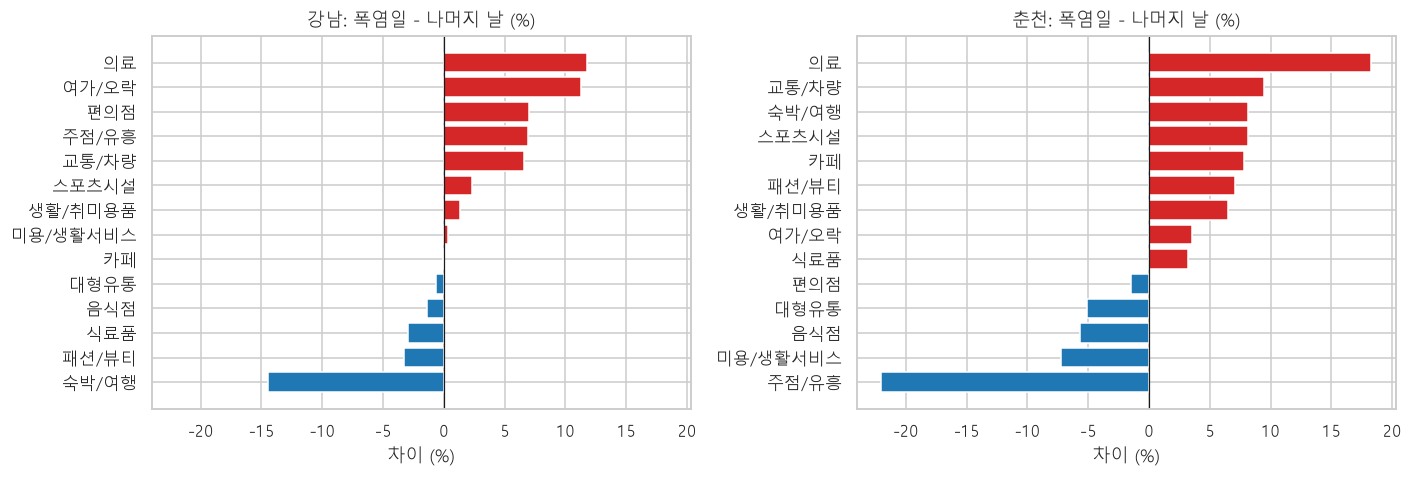

region,강남,춘천
폭염일 - 나머지 날 (%),,
교통/차량,6.600,9.500
대형유통,-0.700,-5.100
미용/생활서비스,0.300,-7.200
생활/취미용품,1.300,6.500
숙박/여행,-14.500,8.100
스포츠시설,2.300,8.100
식료품,-2.900,3.200
여가/오락,11.300,3.500
음식점,-1.300,-5.700


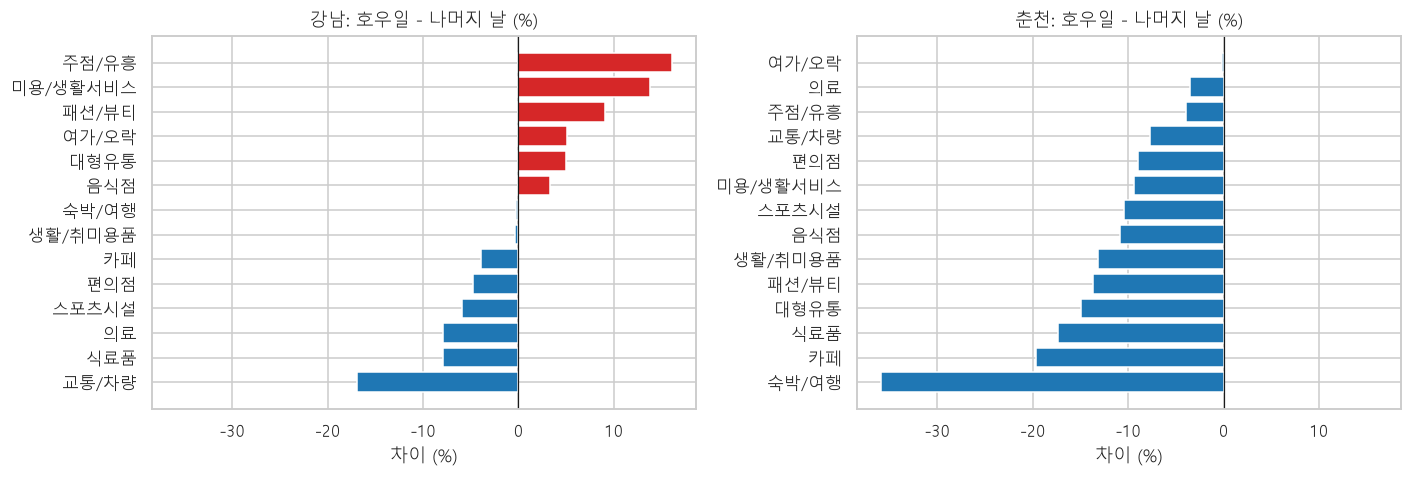

region,강남,춘천
호우일 - 나머지 날 (%),,
교통/차량,-16.900,-7.700
대형유통,5.000,-14.900
미용/생활서비스,13.800,-9.400
생활/취미용품,-0.300,-13.100
숙박/여행,-0.200,-35.900
스포츠시설,-5.900,-10.400
식료품,-7.900,-17.300
여가/오락,5.100,-0.200
음식점,3.300,-10.900


-> 이 방법은 업종그룹마다 무게가 같고, 폭염과 호우가 섞여 있다. 3-3의 회귀 결과와 다를 수 있다.


In [13]:
def 잔차차이(flag):
    # 지역 x 업종그룹별로 (그 날씨인 날 평균 - 나머지 날 평균) x 100
    t = (resid_full.groupby(['region', 'industry_group', flag], observed=True)['resid']
         .mean().unstack(flag) * 100)
    t.columns = ['나머지 날', '해당 날']
    t['차이'] = t['해당 날'] - t['나머지 날']
    return t.reset_index()


for flag, 이름 in [('heat33', '폭염일'), ('rain30', '호우일')]:
    t = 잔차차이(flag)
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharex=True)
    for ax, r in zip(axes, REGIONS):
        g = t[t['region'].eq(r)].sort_values('차이')
        ax.barh(g['industry_group'], g['차이'],
                color=[('tab:red' if v > 0 else 'tab:blue') for v in g['차이']])
        ax.axvline(0, color='k', lw=0.8)
        ax.set(title=f'{r}: {이름} - 나머지 날 (%)', xlabel='차이 (%)')
    plt.tight_layout(); plt.show()
    display(t.pivot(index='industry_group', columns='region', values='차이').round(1)
            .rename_axis(f'{이름} - 나머지 날 (%)'))

print('-> 이 방법은 업종그룹마다 무게가 같고, 폭염과 호우가 섞여 있다. 3-3의 회귀 결과와 다를 수 있다.')

### 3-2. 회귀에 날씨 더미 넣기

In [14]:
WX_VARS = ['heat33[T.True]', 'tropical[T.True]', 'rain30[T.True]']
WX_NAME = {'heat33': '폭염', 'tropical': '열대야', 'rain30': '호우'}


def 효과표(m):
    # 회귀 결과에서 날씨 계수 3개를 뽑아 % 효과와 95% 신뢰구간으로 바꾼다.
    ci = m.conf_int()
    행 = []
    for v in WX_VARS:
        if v not in m.params.index:
            continue
        행.append({'var': v.split('[')[0],
                   'eff': (np.exp(m.params[v]) - 1) * 100,
                   'lo': (np.exp(ci.loc[v, 0]) - 1) * 100,
                   'hi': (np.exp(ci.loc[v, 1]) - 1) * 100,
                   'p': m.pvalues[v]})
    return pd.DataFrame(행)


def 날씨회귀(q, 달력=None, y='y', cluster=None, cov='HC1'):
    # 달력 + 날씨 더미 회귀. cluster에 열을 주면 그 열로 묶어서 표준오차를 계산한다.
    f = f'{y} ~ ' + (CAL_FORMULA if 달력 is None else 달력) + ' + heat33 + tropical + rain30'
    m = smf.ols(f, data=q)
    if cluster is not None:
        return m.fit(cov_type='cluster', cov_kwds={'groups': q[cluster].factorize()[0]})
    return m.fit(cov_type=cov)


# 같은 날의 업종 67개는 같은 날씨를 겪으므로 서로 독립이 아니다.
# 날짜로 묶어(cluster) 표준오차를 계산하지 않으면 신뢰구간이 너무 좁게 나온다.
행 = []
for r in REGIONS:
    q = panel[panel['region'].eq(r) & panel['y'].notna()].copy()
    for 이름, 달력 in [('기본 식', 'C(industry) + ' + CAL_FORMULA),
                       ('월 더미 뺌', 'C(industry) + ' + CAL_FORMULA.replace(' + C(month)', '')),
                       ('월말 더미 더함', 'C(industry) + ' + CAL_FORMULA + ' + is_month_end')]:
        t = 효과표(날씨회귀(q, 달력=달력, cluster='date'))
        t.insert(0, '식', 이름); t.insert(0, '지역', r)
        행.append(t)
효과 = pd.concat(행, ignore_index=True)
효과['날씨'] = 효과['var'].map(WX_NAME)
효과['구간'] = 효과.apply(lambda x: f'[{x["lo"]:+.1f}, {x["hi"]:+.1f}]', axis=1)

for r in REGIONS:
    print(r)
    display(효과[효과['지역'].eq(r)].pivot(index='날씨', columns='식', values='eff')
            [['기본 식', '월 더미 뺌', '월말 더미 더함']].round(1))

print('기본 식의 95% 신뢰구간 (0을 포함하면 "효과가 있다고 말하기 어렵다")')
display(효과[효과['식'].eq('기본 식')].pivot(index='날씨', columns='지역', values='구간'))
print('-> 폭염은 매출을 떨어뜨리지 않는다 (오히려 약간 +, 월말을 통제하면 더 0에 가까워진다).')
print('-> 매출을 확실히 떨어뜨리는 건 춘천의 호우다. 강남 호우는 0-4에서 추석 당일을 뺀 뒤 거의 0이 되었다.')

강남


식,기본 식,월 더미 뺌,월말 더미 더함
날씨,,,
열대야,2.500,-1.900,0.800
폭염,2.400,1.100,1.700
호우,0.300,-2.700,-0.300


춘천


식,기본 식,월 더미 뺌,월말 더미 더함
날씨,,,
열대야,3.800,3.500,2.100
폭염,5.100,4.400,3.800
호우,-10.200,-8.300,-9.200


기본 식의 95% 신뢰구간 (0을 포함하면 "효과가 있다고 말하기 어렵다")


지역,강남,춘천
날씨,,
열대야,"[-1.2, +6.3]","[-3.8, +12.1]"
폭염,"[-0.6, +5.5]","[-0.1, +10.5]"
호우,"[-5.6, +6.6]","[-14.2, -6.0]"


-> 폭염은 매출을 떨어뜨리지 않는다 (오히려 약간 +, 월말을 통제하면 더 0에 가까워진다).
-> 매출을 확실히 떨어뜨리는 건 춘천의 호우다. 강남 호우는 0-4에서 추석 당일을 뺀 뒤 거의 0이 되었다.


### 3-3. 업종그룹별 효과

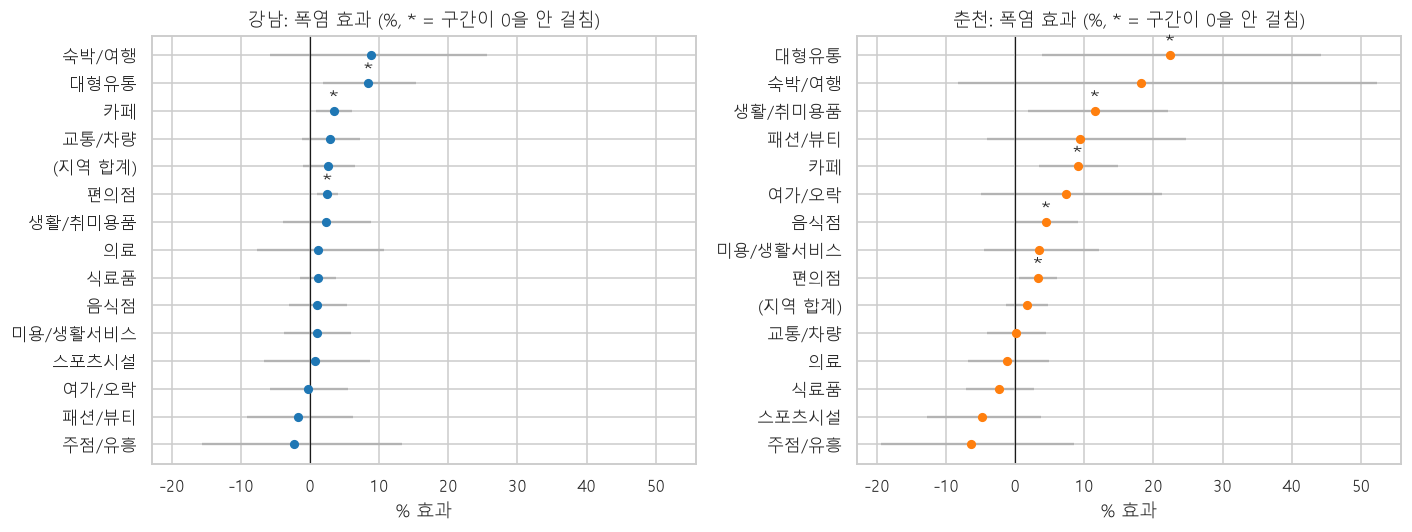

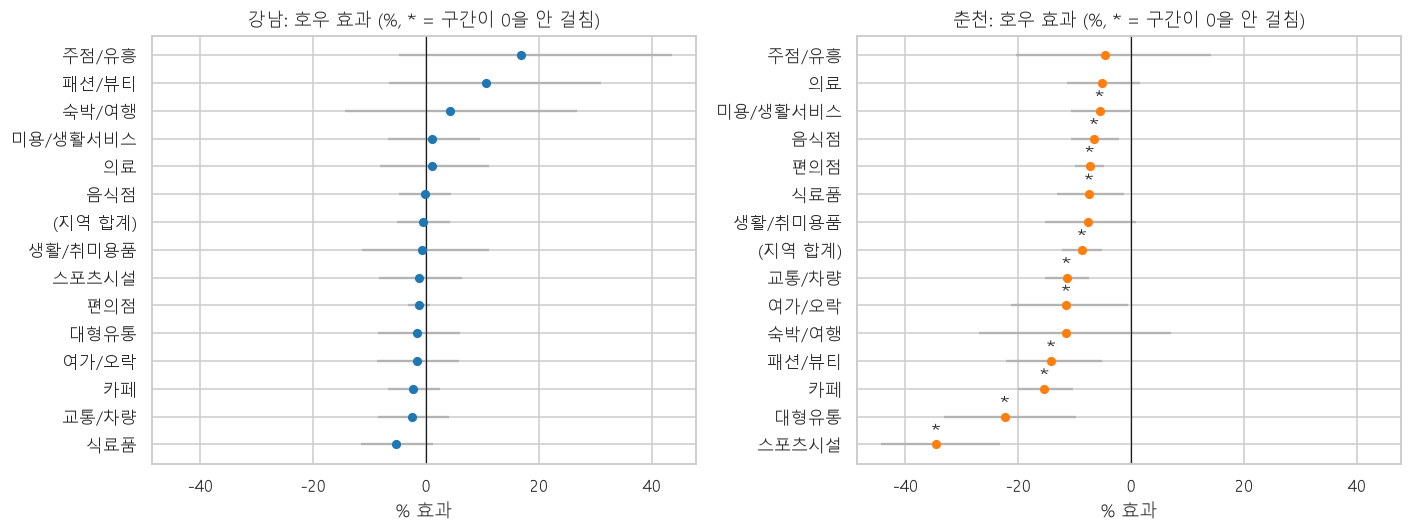

신뢰구간이 0을 안 걸치는 것만


,region,group,var,eff,lo,hi
0,강남,편의점,heat33,2.500,1.000,4.100
1,강남,카페,heat33,3.400,0.900,6.100
2,강남,대형유통,heat33,8.400,1.900,15.400
3,춘천,편의점,heat33,3.300,0.600,6.100
4,춘천,음식점,heat33,4.500,0.100,9.100
5,춘천,카페,heat33,9.000,3.500,14.900
6,춘천,생활/취미용품,heat33,11.500,1.900,22.100
7,춘천,대형유통,heat33,22.400,3.900,44.300
8,춘천,스포츠시설,rain30,-34.600,-44.300,-23.200
9,춘천,대형유통,rain30,-22.400,-33.200,-9.800


지역 합계


region,강남,춘천
var,,
heat33,2.700,1.700
rain30,-0.600,-8.700
tropical,1.500,3.300


-> 더운 날 카페, 편의점, 대형유통(시원한 곳, 시원한 음료)이 오른다.
-> 비 오는 날 춘천은 야외(스포츠시설)와 이동(교통/차량) 업종이 크게 빠진다.


In [15]:
# 지역 합계 일매출도 한 줄 넣기 위해 먼저 만들어 둔다 (5-1, 7장, 8장에서 다시 쓴다)
total = add_wx_cal(base1.groupby(['date', 'region'], as_index=False, observed=True)
                   .agg(amount=('amount', 'sum'), cnt=('cnt', 'sum')))
total['ticket'] = total['amount'] / total['cnt']

행 = []
for r in REGIONS:
    # 업종그룹 14개 + 지역 합계 1개
    대상 = [(g, group[group['region'].eq(r) & group['industry_group'].eq(g)]) for g in GROUPS]
    대상.append(('(지역 합계)', total[total['region'].eq(r)]))
    for 이름, q in 대상:
        t = 효과표(날씨회귀(q, cov='HC1'))   # 업종그룹 하나짜리 184행 회귀라 C(industry)는 필요 없다
        t.insert(0, 'group', 이름); t.insert(0, 'region', r)
        행.append(t)
effects_full = pd.concat(행, ignore_index=True)
effects_full['유의'] = (effects_full['lo'] > 0) | (effects_full['hi'] < 0)   # 신뢰구간이 0을 안 걸침

for v, 이름 in [('heat33', '폭염'), ('rain30', '호우')]:
    fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharex=True)
    for ax, r in zip(axes, REGIONS):
        g = (effects_full[effects_full['region'].eq(r) & effects_full['var'].eq(v)]
             .sort_values('eff').reset_index(drop=True))
        색 = ['k' if s else '0.6' for s in g['유의']]
        ax.errorbar(g['eff'], range(len(g)), xerr=[g['eff'] - g['lo'], g['hi'] - g['eff']],
                    fmt='o', ecolor='0.7', color=REGION_COLOR[r], ms=5)
        for i, (e, s) in enumerate(zip(g['eff'], g['유의'])):
            if s:
                ax.annotate('*', (e, i), textcoords='offset points', xytext=(0, 5), ha='center')
        ax.set_yticks(range(len(g))); ax.set_yticklabels(g['group'])
        ax.axvline(0, color='k', lw=0.8)
        ax.set(title=f'{r}: {이름} 효과 (%, * = 구간이 0을 안 걸침)', xlabel='% 효과')
    plt.tight_layout(); plt.show()

print('신뢰구간이 0을 안 걸치는 것만')
display(effects_full[effects_full['유의'] & effects_full['var'].ne('tropical')]
        .sort_values(['var', 'region', 'eff'])[['region', 'group', 'var', 'eff', 'lo', 'hi']]
        .round(1).reset_index(drop=True))
print('지역 합계')
display(effects_full[effects_full['group'].eq('(지역 합계)')]
        .pivot(index='var', columns='region', values='eff').round(1))
print('-> 더운 날 카페, 편의점, 대형유통(시원한 곳, 시원한 음료)이 오른다.')
print('-> 비 오는 날 춘천은 야외(스포츠시설)와 이동(교통/차량) 업종이 크게 빠진다.')

### 3-4. 임계값 바꿔 보기

강남


,해당 일수,효과(%),p
임계값(℃),,,
30,61,-6.253,0.007
31,56,-1.961,0.421
32,48,0.230,0.918
33,33,2.655,0.158
34,20,4.672,0.012
35,15,4.259,0.066


춘천


,해당 일수,효과(%),p
임계값(℃),,,
30,55,0.973,0.585
31,49,2.361,0.166
32,42,2.189,0.154
33,30,1.671,0.286
34,16,4.850,0.030
35,11,7.219,0.001


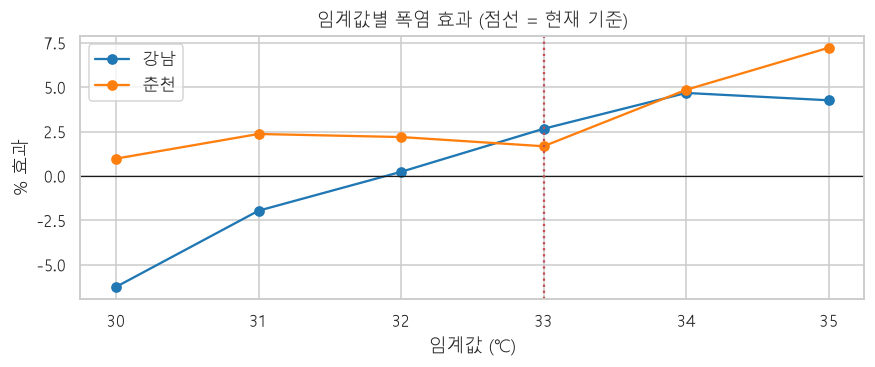

,평년 대비 1℃ 효과(%),p
지역,,
강남,0.217,0.360
춘천,0.427,0.018


-> 아주 더운 날일수록 오히려 매출이 높다. 강남 30℃ 기준에서만 음수가 나온다.
-> 30 ~ 33℃ 날이 따로 무엇인지는 07번에서 확인한다. 35℃ 이상은 날 수가 적어 불안정하다.


In [16]:
# 1) 임계값을 30 ~ 35℃로 바꿔 가며 지역 합계 일매출 회귀
행 = []
for r in REGIONS:
    q = total[total['region'].eq(r)].copy()
    for k in range(30, 36):
        q['hot'] = q['tmax'] >= k
        f = 'y ~ ' + CAL_FORMULA + ' + hot + tropical + rain30'
        m = smf.ols(f, data=q).fit(cov_type='HC1')
        v = 'hot[T.True]'
        행.append({'지역': r, '임계값(℃)': k, '해당 일수': int(q['hot'].sum()),
                   '효과(%)': (np.exp(m.params[v]) - 1) * 100, 'p': m.pvalues[v]})
스윕 = pd.DataFrame(행)
for r in REGIONS:
    print(r)
    display(스윕[스윕['지역'].eq(r)].set_index('임계값(℃)').drop(columns='지역').round(3))

fig, ax = plt.subplots(figsize=(8, 3.5))
for r in REGIONS:
    g = 스윕[스윕['지역'].eq(r)]
    ax.plot(g['임계값(℃)'], g['효과(%)'], 'o-', color=REGION_COLOR[r], label=r)
ax.axhline(0, color='k', lw=0.8)
ax.axvline(THRESH['heat'], ls=':', color='r')
ax.set(xlabel='임계값 (℃)', ylabel='% 효과', title='임계값별 폭염 효과 (점선 = 현재 기준)')
ax.legend()
plt.tight_layout(); plt.show()

# 2) 연속 변수 버전: 평년보다 1℃ 더울 때 매출이 몇 % 달라지나
행 = []
for r in REGIONS:
    q = total[total['region'].eq(r)]
    m = smf.ols('y ~ ' + CAL_FORMULA + ' + tmax_anom + rain30', data=q).fit(cov_type='HC1')
    행.append({'지역': r, '평년 대비 1℃ 효과(%)': (np.exp(m.params['tmax_anom']) - 1) * 100,
               'p': m.pvalues['tmax_anom']})
display(pd.DataFrame(행).set_index('지역').round(3))
print('-> 아주 더운 날일수록 오히려 매출이 높다. 강남 30℃ 기준에서만 음수가 나온다.')
print('-> 30 ~ 33℃ 날이 따로 무엇인지는 07번에서 확인한다. 35℃ 이상은 날 수가 적어 불안정하다.')

**결정**: 폭염 임계값을 정한다. 07번 Q3 결과와 이 표를 같이 보고 적는다. (바꾸면 0-3의 THRESH를 고치고 04번 이벤트 목록도 다시 만들기)

- 결정: **33℃ 유지** (07번 Q3과 같음). 0-3의 `THRESH` 를 바꾸지 않는다.
- 이유: 30 ~ 35℃로 임계값을 옮겨 가며 돌려도 매출이 꺾이는 지점이 없다. 오히려 더 더운 쪽(34, 35℃)에서 효과가 +로 커진다.
  데이터가 특정 값을 지목하지 않으므로 기상청 관례인 33℃를 그대로 쓰는 편이 설명하기 쉽다.
  강남 30℃ 기준에서만 -6.3%(p 0.007)가 나오는데, 이는 30 ~ 33℃ 날들이 따로 무엇인지(요일, 휴가철)의 문제로 보인다. 9-4에 남긴다.

### 3장 정리
- **본 것**: 잔차 평균 비교와 날씨 더미 회귀 두 방법으로 폭염, 열대야, 호우의 % 효과를 재고, 업종그룹 28개 + 지역 합계 2개로 나눠 봤다.
- **나온 것**: 폭염은 매출을 **떨어뜨리지 않는다**(강남 +2.4%, 춘천 +5.1%, 둘 다 구간이 0을 걸침). 매출을 확실히 떨어뜨리는 것은 **춘천의 호우(-10.2%, [-14.2, -6.0])** 뿐이다.
  업종그룹으로 보면 더운 날 카페 +9.0%, 대형유통 +22.4%, 편의점 +3.3%가 오르고(춘천), 비 오는 날 춘천 스포츠시설 -34.6%, 대형유통 -22.4%, 카페 -15.4%가 빠진다. 강남은 호우에 유의한 업종그룹이 하나도 없다.
- **시사점**: 주제의 무게중심을 **호우로 옮겨야 한다**(07번 Q4의 분기와 같은 결론). 폭염은 "매출을 누른다"가 아니라 "업종별로 수요를 옮긴다"로 다시 써야 한다.

## 4. 누구의 매출이, 언제 바뀌나 (순차 분해)
한 번에 업종 × 연령 × 성별 × 시간대로 다 쪼개면 칸이 비어 버린다. 그래서 **업종그룹 -> 연령 -> 성별 -> 시간대** 순서로 한 축씩만 추가한다.
각 축에서 식은 같다: `y ~ C(industry_group) + 달력 + heat33 + tropical + rain30` 을 그 축의 값(예: 20대)마다 따로 돌린다.
시간이 되면 `PRIORITY_GROUPS` 만 남기고 다시 돌려서 결과가 같은지 확인한다. (탐색 문서 Q5: 반응이 큰 업종 몇 개만 쪼개기)

### 4-1. 연령

age_panel 30,877행


지역,강남,춘천
값,,
10대,+0.2,+7.3
20대,+1.2,+8.8
30대,+2.0,+8.5
40대,+1.2,+10.8
50대,+5.1,+3.4
60대 이상,-3.3,-3.5


지역,강남,춘천
값,,
10대,+2.5,+4.3
20대,+1.0,+3.6
30대,+1.9,+11.8
40대,+4.4,+8.9
50대,+2.4,-0.0
60대 이상,+6.8,+6.1


지역,강남,춘천
값,,
10대,-1.3,-8.2
20대,+1.7,-6.1
30대,+3.5,-8.4
40대,-1.3,-9.1
50대,+1.2,-12.6
60대 이상,-1.0,-16.9


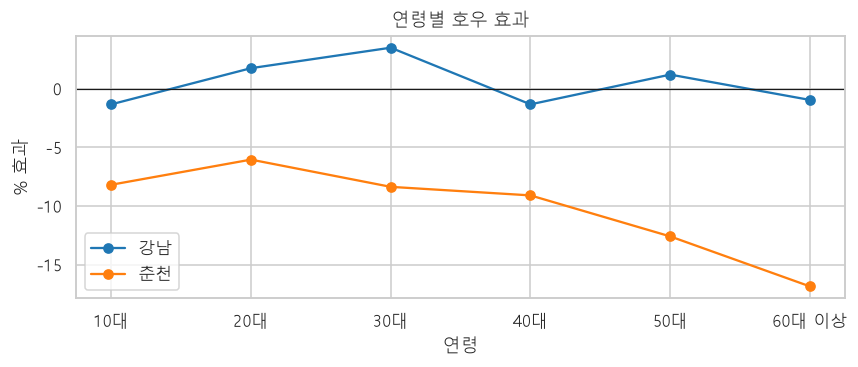

-> 춘천은 나이가 많을수록 비 오는 날 매출이 더 많이 줄어든다. 강남은 모든 연령에서 0 근처다.


In [17]:
def 축패널(축, base=None):
    # 날짜 x 지역 x 업종그룹 x (축) 으로 금액을 더한 표를 만든다.
    b = base1 if base is None else base
    t = b.groupby(['date', 'region', 'industry_group', 축],
                  as_index=False, observed=True).agg(amount=('amount', 'sum'))
    return add_wx_cal(t)


def 축효과(t, 축):
    # 축의 값마다(예: 20대) 따로 회귀를 돌린다. 식은 모두 같다.
    행 = []
    for (r, v), q in t.groupby(['region', 축], observed=True):
        q = q[q['y'].notna()]
        m = 날씨회귀(q, 달력='C(industry_group) + ' + CAL_FORMULA, cluster='date')
        e = 효과표(m)
        e.insert(0, '값', v); e.insert(0, '지역', r)
        행.append(e)
    out = pd.concat(행, ignore_index=True)
    out['날씨'] = out['var'].map(WX_NAME)
    return out


def 효과그림(out, 축이름, 날씨='호우'):
    fig, ax = plt.subplots(figsize=(8, 3.5))
    for r in REGIONS:
        g = out[out['지역'].eq(r) & out['날씨'].eq(날씨)].sort_values('값')
        ax.plot(g['값'], g['eff'], 'o-', color=REGION_COLOR[r], label=r)
    ax.axhline(0, color='k', lw=0.8)
    ax.set(xlabel=축이름, ylabel='% 효과', title=f'{축이름}별 {날씨} 효과')
    ax.legend()
    plt.tight_layout(); plt.show()


def 효과표보기(out, 축이름):
    for 날씨 in ['폭염', '열대야', '호우']:
        t = out[out['날씨'].eq(날씨)]
        표 = t.pivot(index='값', columns='지역', values='eff').round(1)
        유의 = t.pivot(index='값', columns='지역', values='p') < 0.05
        display(표.style.format('{:+.1f}').apply(
            lambda c: np.where(유의[c.name], 'font-weight: bold', ''), axis=0)
            .set_caption(f'{축이름}별 {날씨} 효과 (%, 굵게 = p < 0.05)'))


base1 = base1.copy()
base1['age_g'] = base1['age'].map(AGE_GROUP).fillna(base1['age'])
age_panel = 축패널('age_g')
print(f'age_panel {len(age_panel):,}행')
age_eff = 축효과(age_panel, 'age_g')
효과표보기(age_eff, '연령')
효과그림(age_eff, '연령', '호우')
print('-> 춘천은 나이가 많을수록 비 오는 날 매출이 더 많이 줄어든다. 강남은 모든 연령에서 0 근처다.')

### 4-2. 성별

In [18]:
sex_panel = 축패널('sex')
sex_eff = 축효과(sex_panel, 'sex')
효과표보기(sex_eff, '성별')
print('-> 성별 차이는 작다. 춘천 호우에서 여성이 조금 더 민감한 정도다.')

지역,강남,춘천
값,,
남성,+2.8,+4.9
여성,+3.1,+5.4


지역,강남,춘천
값,,
남성,+3.9,+2.4
여성,+2.5,+8.3


지역,강남,춘천
값,,
남성,+0.7,-11.1
여성,+0.8,-13.2


-> 성별 차이는 작다. 춘천 호우에서 여성이 조금 더 민감한 정도다.


### 4-3. 시간대 (일 단위 날씨)

In [19]:
# 그날의 heat33, rain30을 그 날의 모든 시간대에 똑같이 적용한다.
slot_panel = 축패널('time_gb')
slot_eff = 축효과(slot_panel, 'time_gb')
효과표보기(slot_eff, '시간대')

# 밤형 업종이 많은 시간대(18_23, 00_05)에서 열대야 효과가 있는지 보려고 시간대 유형을 옆에 둔다.
유형표 = (pd.Series(TIME_TYPE).rename('시간대 유형').to_frame()
          .join(group.groupby('industry_group', observed=True)['amount'].sum().rename('금액'))
          .sort_values(['시간대 유형', '금액'], ascending=[True, False]))
display(유형표['시간대 유형'].groupby(유형표['시간대 유형']).count().rename('업종그룹 수').to_frame().T)
print('-> 비는 출근, 오전 시간대(06_11)를 가장 세게 때린다.')
print('-> 폭염의 한낮 효과(12_17 음수)는 강남에서만 약하게 보이고 유의하지 않다.')
print('-> 춘천 00_05 열대야는 열대야가 5일뿐이라 값이 크게 흔들린다. 숫자를 믿기 어렵다.')

지역,강남,춘천
값,,
00_05,+3.4,+9.9
06_11,+1.3,+7.7
12_17,-2.9,+7.4
18_23,+2.7,+5.2


지역,강남,춘천
값,,
00_05,+4.6,-18.2
06_11,+1.1,+1.6
12_17,+2.3,+4.4
18_23,+2.7,+4.7


지역,강남,춘천
값,,
00_05,+4.3,-6.6
06_11,-6.9,-16.9
12_17,-2.4,-10.0
18_23,-3.9,-14.5


시간대 유형,밤형,오전형,오후형,종일형
업종그룹 수,3,2,3,6


-> 비는 출근, 오전 시간대(06_11)를 가장 세게 때린다.
-> 폭염의 한낮 효과(12_17 음수)는 강남에서만 약하게 보이고 유의하지 않다.
-> 춘천 00_05 열대야는 열대야가 5일뿐이라 값이 크게 흔들린다. 숫자를 믿기 어렵다.


### 4-4. 시간대별 기온으로 다시 보기

In [20]:
# 4-3은 "그날 최고기온"을 모든 시간대에 똑같이 썼다. wx_slot에는 시간대마다 최고기온이 따로 있다.
slot2 = slot_panel.merge(wx_slot, on=['date', 'region', 'time_gb'])
slot2['slot_hot'] = slot2['temp_max'] >= THRESH['heat']
print(f'slot2 {len(slot2):,}행')

일수 = (slot2.drop_duplicates(['date', 'region', 'time_gb'])
        .groupby(['region', 'time_gb'], observed=True)['slot_hot'].sum().unstack())
display(일수.rename_axis('시간대별 33℃ 넘은 날 수'))

# 폭염일의 12_17 시간대에 33℃ 이상이었던 시간 수
display(slot2[slot2['heat33'] & slot2['time_gb'].eq('12_17')]
        .drop_duplicates(['date', 'region'])
        .groupby('region')['hours_ge33'].mean().round(1).rename('평균 시간').to_frame().T)

행 = []
for (r, s), q in slot2.groupby(['region', 'time_gb'], observed=True):
    q = q[q['y'].notna()]
    if q['slot_hot'].sum() == 0:          # 그 시간대에 33℃를 넘은 날이 하루도 없으면 회귀가 안 된다
        continue
    f = 'y ~ C(industry_group) + ' + CAL_FORMULA + ' + slot_hot + tropical + rain30'
    m = smf.ols(f, data=q).fit(cov_type='cluster', cov_kwds={'groups': q['date'].factorize()[0]})
    v = 'slot_hot[T.True]'
    행.append({'지역': r, '시간대': s, '해당 일수': int(q.drop_duplicates('date')['slot_hot'].sum()),
               '효과(%)': (np.exp(m.params[v]) - 1) * 100, 'p': m.pvalues[v]})
display(pd.DataFrame(행).set_index(['지역', '시간대']).round(3))
print('-> 시간대 기온으로 봐도 4-3과 같은 결론이다. 한낮이 뜨거워도 매출은 안 빠진다.')
print('-> 다만 시간대가 6시간 단위라 14 ~ 16시 피크가 12_17 안에 묻히는 한계는 남는다.')

slot2 20,583행


time_gb,00_05,06_11,12_17,18_23
시간대별 33℃ 넘은 날 수,,,,
강남,0,12,33,17
춘천,0,0,24,11


region,강남,춘천
평균 시간,4.200,3.100


해당 일수  효과(%)     p
지역 시간대                      
강남 06_11     12  9.694 0.064
   12_17     33 -2.945 0.346
   18_23     17  2.148 0.259
춘천 12_17     24  8.015 0.017
   18_23     11  3.607 0.394

-> 시간대 기온으로 봐도 4-3과 같은 결론이다. 한낮이 뜨거워도 매출은 안 빠진다.
-> 다만 시간대가 6시간 단위라 14 ~ 16시 피크가 12_17 안에 묻히는 한계는 남는다.


### 4장 정리
- **본 것**: 업종그룹 -> 연령 -> 성별 -> 시간대 순서로 한 축씩만 더해 같은 회귀를 돌렸고, 마지막에는 시간대별 기온(`wx_slot`)으로도 다시 봤다.
- **나온 것**: 춘천 호우는 **나이가 많을수록 크게 빠지고**(20대 -6.1% -> 60대 이상 -16.9%), **오전(06_11) -16.9%**가 가장 세다. 성별 차이는 작다(여성이 2%p 정도 더 민감).
  폭염은 어느 축에서도 뚜렷한 음수가 없다. 시간대 기온으로 봐도 한낮(12_17)은 강남 -2.9%(p 0.35), 춘천 +8.0%(p 0.02)다.
- **시사점**: 호우의 피해는 "이동이 필요한 사람"에게 몰린다(오전 + 고령). [추론] 고령층이 더 크게 빠지는 것은 이동 수단, 야외 활동 비중 차이로 보이지만 이 데이터만으로는 확인할 수 없다.
  시간대가 6시간 단위라 14 ~ 16시 폭염 피크가 12_17 안에 묻히는 한계는 그대로 남는다.

## 5. 사람이 안 온 건가, 와서 덜 쓴 건가
매출 = 건수 × 객단가 이다. 로그를 쓰면 **log(매출) = log(건수) + log(객단가)** 라서, 같은 식으로 회귀하면 계수도 정확히 더해진다.
건수가 줄었으면 "안 왔다", 객단가가 줄었으면 "와서 덜 썼다"로 읽는다. (탐색 문서 Q6)

### 5-1. 건수와 객단가로 나누기

In [21]:
# log(매출) = log(건수) + log(객단가) 이므로, 같은 식으로 회귀하면 계수도 정확히 더해진다.
def 분해(q):
    q = q[(q['amount'] > 0) & (q['cnt'] > 0)].copy()
    q['y_amt'] = np.log(q['amount'])
    q['y_cnt'] = np.log(q['cnt'])
    q['y_tic'] = np.log(q['amount'] / q['cnt'])
    out = {}
    for 이름, col in [('매출', 'y_amt'), ('건수', 'y_cnt'), ('객단가', 'y_tic')]:
        m = 날씨회귀(q, y=col, cov='HC1')
        out[이름] = {v.split('[')[0]: m.params[v] for v in WX_VARS}
    return pd.DataFrame(out)


print('지역 합계 (로그 계수 그대로. 건수 + 객단가 = 매출 인지 확인)')
for r in REGIONS:
    t = 분해(total[total['region'].eq(r)])
    t['건수 + 객단가'] = t['건수'] + t['객단가']
    t.index = t.index.map(WX_NAME)
    print(r); display(t.round(3))

행 = []
for r in REGIONS:
    for g in GROUPS:
        t = 분해(group[group['region'].eq(r) & group['industry_group'].eq(g)])
        for v in ['heat33', 'rain30']:
            행.append({'지역': r, '업종그룹': g, '날씨': WX_NAME[v],
                       '매출(%)': (np.exp(t.loc[v, '매출']) - 1) * 100,
                       '건수(%)': (np.exp(t.loc[v, '건수']) - 1) * 100,
                       '객단가(%)': (np.exp(t.loc[v, '객단가']) - 1) * 100})
분해표 = pd.DataFrame(행)
for 날씨 in ['폭염', '호우']:
    t = 분해표[분해표['날씨'].eq(날씨)].drop(columns='날씨')
    print(f'{날씨}: 매출 변화가 큰 순서로 10개')
    display(t.reindex(t['매출(%)'].abs().sort_values(ascending=False).index)
            .head(10).round(1).reset_index(drop=True))
print('-> 춘천 호우의 매출 감소는 거의 전부 건수(방문) 감소다. 와서 덜 쓴 게 아니라 안 온 것이다.')
print('-> 예외: 춘천 스포츠시설은 객단가가 더 크게 빠진다(골프처럼 큰 결제가 사라짐).')
print('-> 춘천 대형유통 폭염은 건수가 줄고 객단가가 크게 올랐다(적게 와서 많이 삼).')

지역 합계 (로그 계수 그대로. 건수 + 객단가 = 매출 인지 확인)
강남


,매출,건수,객단가,건수 + 객단가
폭염,0.026,0.025,0.001,0.026
열대야,0.015,0.014,0.001,0.015
호우,-0.006,-0.039,0.033,-0.006


춘천


,매출,건수,객단가,건수 + 객단가
폭염,0.017,0.019,-0.002,0.017
열대야,0.032,0.010,0.022,0.032
호우,-0.091,-0.100,0.009,-0.091


폭염: 매출 변화가 큰 순서로 10개


,지역,업종그룹,매출(%),건수(%),객단가(%)
0,춘천,대형유통,22.400,-5.800,29.900
1,춘천,숙박/여행,18.200,22.600,-3.600
2,춘천,생활/취미용품,11.500,3.500,7.800
3,춘천,패션/뷰티,9.400,10.100,-0.600
4,춘천,카페,9.000,8.500,0.500
5,강남,숙박/여행,8.800,7.100,1.600
6,강남,대형유통,8.400,6.100,2.200
7,춘천,여가/오락,7.300,7.800,-0.400
8,춘천,주점/유흥,-6.400,-5.900,-0.600
9,춘천,스포츠시설,-4.900,3.800,-8.300


호우: 매출 변화가 큰 순서로 10개


,지역,업종그룹,매출(%),건수(%),객단가(%)
0,춘천,스포츠시설,-34.600,-10.500,-26.900
1,춘천,대형유통,-22.400,-19.400,-3.700
2,강남,주점/유흥,16.900,8.100,8.100
3,춘천,카페,-15.400,-14.300,-1.300
4,춘천,패션/뷰티,-14.200,-15.500,1.600
5,춘천,숙박/여행,-11.600,-6.400,-5.600
6,춘천,여가/오락,-11.500,-8.400,-3.400
7,춘천,교통/차량,-11.500,-11.400,-0.000
8,강남,패션/뷰티,10.700,-4.400,15.800
9,춘천,생활/취미용품,-7.600,-12.800,5.900


-> 춘천 호우의 매출 감소는 거의 전부 건수(방문) 감소다. 와서 덜 쓴 게 아니라 안 온 것이다.
-> 예외: 춘천 스포츠시설은 객단가가 더 크게 빠진다(골프처럼 큰 결제가 사라짐).
-> 춘천 대형유통 폭염은 건수가 줄고 객단가가 크게 올랐다(적게 와서 많이 삼).


### 5-2. 외지인이 먼저 빠지는가

In [22]:
# 1) 지역 x 날짜별 외지인 금액과 현지인 금액
out_daily = (outsider.groupby(['date', 'region'], as_index=False, observed=True)
             .agg(amount_total=('amount_total', 'sum'), amount_outsider=('amount_outsider', 'sum')))
out_daily['amount_local'] = out_daily['amount_total'] - out_daily['amount_outsider']
out_daily['share'] = out_daily['amount_outsider'] / out_daily['amount_total'] * 100
out_daily = out_daily.merge(calendar, on='date').merge(wx, on=['date', 'region'])
out_daily['y_out'] = np.log(out_daily['amount_outsider'])
out_daily['y_loc'] = np.log(out_daily['amount_local'])
display(out_daily.groupby('region')['share'].mean().round(1).rename('외지인 비중 평균(%)').to_frame().T)

행 = []
for r in REGIONS:
    q = out_daily[out_daily['region'].eq(r)]
    for 이름, col in [('외지인 금액(%)', 'y_out'), ('현지인 금액(%)', 'y_loc'), ('외지인 비중(%p)', 'share')]:
        m = 날씨회귀(q, y=col, cov='HC1')
        for v in ['heat33', 'rain30']:
            계수 = m.params[v + '[T.True]']
            행.append({'지역': r, '날씨': WX_NAME[v], '대상': 이름,
                       '효과': 계수 if col == 'share' else (np.exp(계수) - 1) * 100,
                       'p': m.pvalues[v + '[T.True]']})
외지인효과 = pd.DataFrame(행)
for 날씨 in ['폭염', '호우']:
    t = 외지인효과[외지인효과['날씨'].eq(날씨)]
    display(t.pivot(index='대상', columns='지역', values='효과').round(1)
            .rename_axis(f'{날씨} 효과'))
    display(t.pivot(index='대상', columns='지역', values='p').round(3).rename_axis('p값'))

# 2) 춘천만 업종그룹별 외지인 금액의 호우 효과
q = outsider[outsider['region'].eq('춘천') & (outsider['amount_outsider'] > 0)].merge(
    calendar, on='date').merge(wx, on=['date', 'region'])
q['y_out'] = np.log(q['amount_outsider'])
행 = []
for g, sub in q.groupby('industry_group', observed=True):
    m = 날씨회귀(sub, y='y_out', cov='HC1')
    행.append({'업종그룹': g,
               '호우 효과(%)': (np.exp(m.params['rain30[T.True]']) - 1) * 100,
               'p': m.pvalues['rain30[T.True]']})
display(pd.DataFrame(행).sort_values('호우 효과(%)').set_index('업종그룹').round(2)
        .rename_axis('춘천 외지인 금액'))
print('-> 비 오는 날 춘천은 외지인(관광, 골프 손님)이 현지인보다 3배 가까이 크게 빠진다.')
print('-> 강남은 외지인도 현지인도 비에 반응하지 않는다.')

region,강남,춘천
외지인 비중 평균(%),48.100,18.300


지역,강남,춘천
폭염 효과,,
외지인 금액(%),2.800,2.700
외지인 비중(%p),0.100,0.200
현지인 금액(%),2.500,1.400


지역,강남,춘천
p값,,
외지인 금액(%),0.238,0.466
외지인 비중(%p),0.865,0.700
현지인 금액(%),0.124,0.309


지역,강남,춘천
호우 효과,,
외지인 금액(%),-1.300,-18.700
외지인 비중(%p),-0.400,-2.100
현지인 금액(%),0.200,-6.400


지역,강남,춘천
p값,,
외지인 금액(%),0.598,0.000
외지인 비중(%p),0.303,0.000
현지인 금액(%),0.952,0.000


,호우 효과(%),p
춘천 외지인 금액,,
스포츠시설,-52.480,0.000
대형유통,-29.340,0.000
여가/오락,-27.910,0.010
카페,-20.450,0.000
교통/차량,-14.470,0.000
생활/취미용품,-13.660,0.200
숙박/여행,-13.640,0.210
음식점,-11.550,0.000
편의점,-11.150,0.000


-> 비 오는 날 춘천은 외지인(관광, 골프 손님)이 현지인보다 3배 가까이 크게 빠진다.
-> 강남은 외지인도 현지인도 비에 반응하지 않는다.


### 5장 정리
- **본 것**: log(매출) = log(건수) + log(객단가)로 쪼개고, 외지인 금액과 현지인 금액을 나눠 날씨 효과를 봤다.
- **나온 것**: 춘천 호우의 매출 감소 -0.091은 **건수 -0.100 + 객단가 +0.009** 로, 거의 전부가 방문 감소다(07번 Q6과 같음).
  예외는 춘천 스포츠시설(객단가 -26.9%: 골프 같은 큰 결제가 사라짐)과 춘천 대형유통 폭염(건수 -5.8%, 객단가 +29.9%: 적게 와서 많이 삼).
  외지인은 -18.7%, 현지인은 -6.4%로 **외지인이 3배 가까이 크게 빠지고** 외지인 비중도 -2.1%p 내려간다. 강남은 외지인도 현지인도 반응이 없다.
- **시사점**: "비가 오면 춘천에 안 온다"가 핵심 경로다. 회복 정책의 대상은 현지 소비가 아니라 **외지 방문**이다.

## 6. (B) 이벤트 스터디 준비: 창이 겹치는 문제
**이벤트 스터디** = 사건이 시작된 날을 0일로 맞춰 놓고, 그 전후 며칠의 매출 궤적을 사건마다 겹쳐서 평균 내는 방법이다.
그런데 2025년 여름은 폭염이 며칠 간격으로 계속 이어져서, 한 사건의 창(-7일 ~ +14일) 안에 다른 사건이 끼어든다. 먼저 이 문제가 얼마나 심한지 센다.

> 04번에서 이미 확인한 사실: 폭염 구간 사이 간격의 중앙값은 강남 2일, 춘천 3일이고, **-7일 ~ +14일 창이 깨끗한 폭염 구간은 하나도 없다.**
> 그래서 0-3의 `WINDOW` 잠정값을 (-3, 7)로 줄였다. 호우도 폭염과 똑같은 무게로 다룬다 (3장에서 매출을 확실히 떨어뜨린 건 호우였음).

### 6-1. 이벤트 목록과 간격

구간_수  총_일수  가장_긴_구간  간격_중앙값  간격_3일_이하
이벤트 region                                       
폭염  강남        10    33       12   2.000         6
    춘천        10    30       12   3.000         6
호우  강남         8    10        2   7.000         3
    춘천        14    18        3   5.000         6

폭염 강남: 가장 긴 구간 07/22 ~ 08/02 (12일)
폭염 춘천: 가장 긴 구간 07/22 ~ 08/02 (12일)
호우 강남: 가장 긴 구간 07/16 ~ 07/17 (2일)
호우 춘천: 가장 긴 구간 07/15 ~ 07/17 (3일)


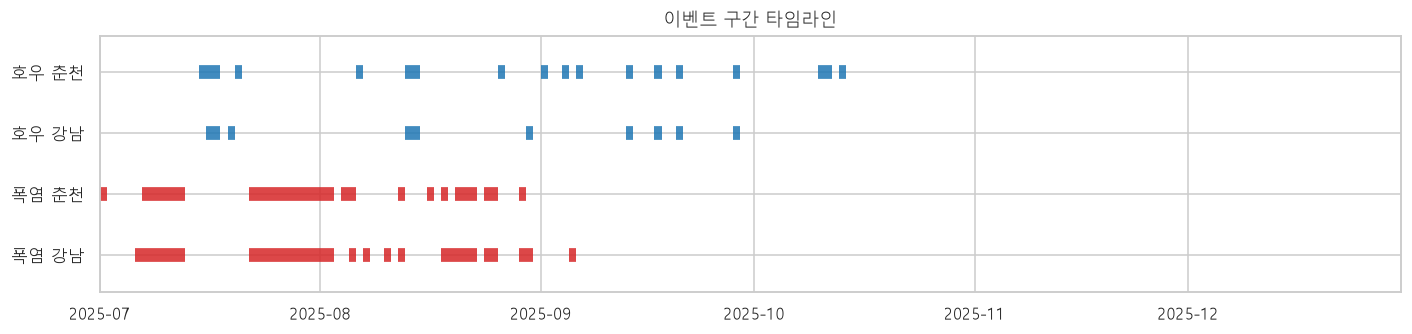

-> 폭염 구간 사이가 2 ~ 3일밖에 안 된다. -7일 ~ +14일 창은 거의 모두 다음 구간과 겹칠 것이다.


In [23]:
EV_NAME = {'heat33': '폭염', 'rain30': '호우'}
DAYS = pd.DatetimeIndex(sorted(calendar['date'].unique()))   # 분석 기간 7/1 ~ 12/31

요약 = (events.groupby(['event', 'region'])
        .agg(구간_수=('spell_id', 'size'), 총_일수=('length_days', 'sum'),
             가장_긴_구간=('length_days', 'max'), 간격_중앙값=('gap_to_prev_days', 'median'))
        .reset_index())
요약['간격_3일_이하'] = [int((events[events['event'].eq(e) & events['region'].eq(r)]['gap_to_prev_days'] <= 3).sum())
                    for e, r in zip(요약['event'], 요약['region'])]
요약['이벤트'] = 요약['event'].map(EV_NAME)
display(요약.set_index(['이벤트', 'region']).drop(columns='event'))

for ev in ['heat33', 'rain30']:
    for r in REGIONS:
        e = events[events['event'].eq(ev) & events['region'].eq(r)]
        긴 = e.loc[e['length_days'].idxmax()]
        print(f'{EV_NAME[ev]} {r}: 가장 긴 구간 {긴["start"]:%m/%d} ~ {긴["end"]:%m/%d} ({긴["length_days"]}일)')

fig, ax = plt.subplots(figsize=(13, 3.2))
줄 = [(ev, r) for ev in ['heat33', 'rain30'] for r in REGIONS]
for i, (ev, r) in enumerate(줄):
    e = events[events['event'].eq(ev) & events['region'].eq(r)]
    # 구간마다 가로 막대 하나. 하루짜리 구간도 보이도록 끝에 하루를 더한다.
    ax.hlines([i] * len(e), e['start'], e['end'] + pd.Timedelta(days=1),
              lw=9, color=('tab:red' if ev == 'heat33' else 'tab:blue'), alpha=0.85)
ax.set_yticks(range(len(줄)))
ax.set_yticklabels([f'{EV_NAME[ev]} {r}' for ev, r in 줄])
ax.set(xlim=(DAYS[0], DAYS[-1]), ylim=(-0.6, len(줄) - 0.4), title='이벤트 구간 타임라인')
plt.tight_layout(); plt.show()
print('-> 폭염 구간 사이가 2 ~ 3일밖에 안 된다. -7일 ~ +14일 창은 거의 모두 다음 구간과 겹칠 것이다.')

### 6-2. 깨끗한 창 세기

In [24]:
def 날짜별표시(ev, r):
    # 그 지역의 날짜별 True/False (폭염일인가, 호우일인가)
    return wx[wx['region'].eq(r)].set_index('date')[ev].reindex(DAYS).fillna(False)


def 깨끗한가(구간, 표시, 창):
    # 창 = (시작 며칠 전, 시작 며칠 후). 창이 분석 기간을 벗어나거나,
    # 창 안에 자기 구간이 아닌 같은 종류의 이벤트 날이 있으면 깨끗하지 않다.
    s, e = 구간['start'], 구간['end']
    lo, hi = s + pd.Timedelta(days=창[0]), s + pd.Timedelta(days=창[1])
    if lo < DAYS[0] or hi > DAYS[-1]:
        return False
    win = 표시.loc[lo:hi]
    자기구간 = (win.index >= s) & (win.index <= e)
    return bool(win[~자기구간].sum() == 0)


def 깨끗한창수(창):
    행 = {}
    for ev in ['heat33', 'rain30']:
        for r in REGIONS:
            표시 = 날짜별표시(ev, r)
            e = events[events['event'].eq(ev) & events['region'].eq(r)]
            행[(EV_NAME[ev], r)] = f'{sum(깨끗한가(x, 표시, 창) for _, x in e.iterrows())}/{len(e)}'
    return 행


print('창 길이별 깨끗한 구간 수 (시작일 기준)')
display(pd.DataFrame({str(창): 깨끗한창수(창) for 창 in [(-7, 14), (-3, 7), (-2, 3)]}).T)

앞뒤같이 = {}
for n in [1, 2, 3, 5, 7, 14]:
    앞뒤같이[f'±{n}일'] = {k: int(v.split('/')[0]) for k, v in 깨끗한창수((-n, n)).items()}
display(pd.DataFrame(앞뒤같이).T)
print('(07번 Q7은 구간 전체 기준(시작 - n일 ~ 종료 + n일)으로 세서 숫자가 조금 더 작다)')

# 다른 종류와 겹치는 것도 센다: -7 ~ +14일 폭염 창 안에 호우일이 있는 구간 수
for r in REGIONS:
    표시 = 날짜별표시('rain30', r)
    e = events[events['event'].eq('heat33') & events['region'].eq(r)]
    겹침 = sum(표시.loc[max(x['start'] - pd.Timedelta(days=7), DAYS[0]):
                      min(x['start'] + pd.Timedelta(days=14), DAYS[-1])].sum() > 0
              for _, x in e.iterrows())
    print(f'{r}: -7 ~ +14일 폭염 창 안에 호우일이 끼어 있는 구간 {겹침}/{len(e)}개')

print('-> 계획했던 -7 ~ +14일 창으로는 폭염 이벤트 스터디를 깨끗하게 할 수 없다.')
print('-> 그래서 7장은 WINDOW =', WINDOW, '로 하고, 창이 겹친다는 사실을 그래프마다 적어 둔다.')

창 길이별 깨끗한 구간 수 (시작일 기준)


폭염         호우      
            강남    춘천   강남    춘천
(-7, 14)  0/10  0/10  2/8  0/14
(-3, 7)   3/10  3/10  3/8  2/14
(-2, 3)   5/10  4/10  5/8  8/14

폭염    호우    
      강남 춘천 강남  춘천
±1일   10  9  8  14
±2일    5  4  7  11
±3일    5  4  4   6
±5일    4  2  3   4
±7일    1  1  3   1
±14일   0  0  1   0

(07번 Q7은 구간 전체 기준(시작 - n일 ~ 종료 + n일)으로 세서 숫자가 조금 더 작다)
강남: -7 ~ +14일 폭염 창 안에 호우일이 끼어 있는 구간 10/10개
춘천: -7 ~ +14일 폭염 창 안에 호우일이 끼어 있는 구간 10/10개
-> 계획했던 -7 ~ +14일 창으로는 폭염 이벤트 스터디를 깨끗하게 할 수 없다.
-> 그래서 7장은 WINDOW = (-3, 7) 로 하고, 창이 겹친다는 사실을 그래프마다 적어 둔다.


### 6-3. 대안: 가까운 구간 합치기

In [25]:
def 구간합치기(e, 최대간격=3):
    # 앞 구간이 끝나고 최대간격일 안에 다시 시작하면 한 번의 긴 이벤트로 본다.
    묶음 = []
    for _, x in e.sort_values('start').iterrows():
        if 묶음 and (x['start'] - 묶음[-1][1]).days - 1 <= 최대간격:
            묶음[-1][1] = max(묶음[-1][1], x['end'])
        else:
            묶음.append([x['start'], x['end']])
    out = pd.DataFrame(묶음, columns=['start', 'end'])
    out['length_days'] = (out['end'] - out['start']).dt.days + 1
    return out


for ev in ['heat33', 'rain30']:
    for r in REGIONS:
        e = events[events['event'].eq(ev) & events['region'].eq(r)]
        m = 구간합치기(e)
        표시 = 날짜별표시(ev, r)
        깨끗 = sum(깨끗한가(x, 표시, (-7, 14)) for _, x in m.iterrows())
        구간글 = ', '.join(f'{s:%m/%d}' + (f' ~ {t:%m/%d}' if s != t else '')
                        for s, t in zip(m['start'], m['end']))
        print(f'{EV_NAME[ev]} {r}: {len(e)}구간 -> {len(m)}구간, -7 ~ +14일이 깨끗한 구간 {깨끗}개')
        print(f'    {구간글}')

print('-> 합쳐도 폭염은 깨끗한 표본이 1개뿐이다. 호우는 합치면 쓸 만해진다(강남 4/5, 춘천 2/8).')
print('-> 폭염은 구간 평균보다, 여름이 끝나는 한 번의 전환(7-5)을 보는 쪽이 현실적이다.')

폭염 강남: 10구간 -> 4구간, -7 ~ +14일이 깨끗한 구간 1개
    07/06 ~ 07/12, 07/22 ~ 08/12, 08/18 ~ 08/30, 09/05
폭염 춘천: 10구간 -> 4구간, -7 ~ +14일이 깨끗한 구간 1개
    07/01, 07/07 ~ 07/12, 07/22 ~ 08/05, 08/12 ~ 08/29
호우 강남: 8구간 -> 5구간, -7 ~ +14일이 깨끗한 구간 4개
    07/16 ~ 07/19, 08/13 ~ 08/14, 08/30, 09/13 ~ 09/20, 09/28
호우 춘천: 14구간 -> 8구간, -7 ~ +14일이 깨끗한 구간 2개
    07/15 ~ 07/20, 08/06, 08/13 ~ 08/14, 08/26, 09/01 ~ 09/06, 09/13 ~ 09/20, 09/28, 10/10 ~ 10/13
-> 합쳐도 폭염은 깨끗한 표본이 1개뿐이다. 호우는 합치면 쓸 만해진다(강남 4/5, 춘천 2/8).
-> 폭염은 구간 평균보다, 여름이 끝나는 한 번의 전환(7-5)을 보는 쪽이 현실적이다.


**결정**: 이벤트 창과 대안을 정한다. 07번 Q7 결과와 같이 본다.
(예: "창은 -3 ~ +7일. 폭염은 창 겹침을 인정하고 모든 구간 평균을 참고로만 보며, 핵심은 7-5 여름 끝 전환. 호우는 가까운 구간을 합친 목록도 같이 본다")
바꾸면 0-3의 `WINDOW` 를 고치고 8~8장을 다시 실행한다.

- 결정: **창은 `WINDOW = (-3, 7)`**. 폭염은 창이 겹친다는 사실을 인정하고 모든 구간 평균을 참고로만 보며, 핵심 근거는 **7-5의 여름 끝 전환 한 번**으로 삼는다.
  호우는 기본 목록(강남 8, 춘천 14구간)을 쓰되, 6-3에서 합친 목록(강남 5구간 중 4개가 -7 ~ +14일 깨끗)도 같이 확인한다.
- 이유: -7 ~ +14일 창이 깨끗한 폭염 구간은 두 지역 모두 0개이고, -7 ~ +14일 폭염 창 20개 전부에 호우일이 끼어 있다. 이 창으로는 폭염 이벤트 스터디를 할 수 없다.
  (-3, 7)로 줄이면 폭염 3개, 호우 3개(강남) / 2개(춘천)가 깨끗해진다. (-2, 3)까지 줄이면 깨끗한 구간은 늘지만 회복을 볼 기간(종료 후 4 ~ 7일)이 사라진다.
  [추론] 구간을 합치는 방식(6-3)은 "간격 3일 이하"라는 기준을 우리가 정한 것이라, 주 결과가 아니라 보조 확인으로만 쓴다.

### 6-4. 평상일로만 배운 기준선

In [26]:
# 2장의 기준선은 폭염일, 호우일까지 넣어 학습했다. 이벤트 스터디에서는 "평소"를 더 깨끗하게 잡으려고
# 폭염도 호우도 아닌 날(평상일)로만 회귀를 학습하고, 그 식으로 모든 날의 기준선을 예측한다.
group['normal'] = ~(group['heat33'] | group['rain30'])
total['normal'] = ~(total['heat33'] | total['rain30'])
display(total.groupby('region')['normal'].sum().rename('평상일 수').to_frame().T)

행 = []
for r in REGIONS:
    대상 = [(g, group[group['region'].eq(r) & group['industry_group'].eq(g)]) for g in GROUPS]
    대상.append(('(지역 합계)', total[total['region'].eq(r)]))
    for 이름, q in 대상:
        q = q.copy()
        m = smf.ols('y ~ ' + CAL_FORMULA, data=q[q['normal']]).fit()
        q['resid'] = q['y'] - m.predict(q)        # 모든 날에 대해 실제 - 예측
        q['industry_group'] = 이름
        행.append(q[['date', 'region', 'industry_group', 'resid', 'normal', 'heat33', 'rain30']])
resid_ev = pd.concat(행, ignore_index=True)
print(f'resid_ev {len(resid_ev):,}행')

소음 = (resid_ev[resid_ev['normal']].groupby(['region', 'industry_group'], observed=True)['resid']
        .std().unstack('region') * 100)
display(소음.sort_values('춘천').round(1).rename_axis('평상일 잔차 표준편차 (%)'))
print('-> 하루 흔들림이 지역 합계로도 7 ~ 9%다. 사건 하나로는 3 ~ 5% 효과를 가려낼 수 없다.')
print('-> 여러 사건을 평균 내야 하는 이유이고, 8-1의 RECOVERY_BAND를 너무 좁게 잡으면 안 되는 이유다.')

region,강남,춘천
평상일 수,142,136


resid_ev 5,520행


region,강남,춘천
평상일 잔차 표준편차 (%),,
편의점,4.600,4.200
(지역 합계),8.900,6.900
음식점,8.000,7.000
카페,6.100,8.400
교통/차량,9.700,8.900
의료,18.900,11.400
미용/생활서비스,11.100,12.300
생활/취미용품,12.400,14.400
식료품,5.900,14.500


-> 하루 흔들림이 지역 합계로도 7 ~ 9%다. 사건 하나로는 3 ~ 5% 효과를 가려낼 수 없다.
-> 여러 사건을 평균 내야 하는 이유이고, 8-1의 RECOVERY_BAND를 너무 좁게 잡으면 안 되는 이유다.


### 6장 정리
- **본 것**: 이벤트 구간의 간격과 창 겹침을 세고, 평상일(폭염도 호우도 아닌 날)로만 학습한 기준선을 따로 만들었다.
- **나온 것**: 폭염 구간 간격 중앙값은 강남 2일, 춘천 3일이고 **-7 ~ +14일이 깨끗한 폭염 구간은 0개**다. 합쳐도 깨끗한 구간은 1개뿐이다.
  평상일은 강남 142일, 춘천 136일이고, 평상일 잔차 표준편차는 지역 합계 8.9% / 6.9%, 편의점 4.6% / 4.2%(가장 안정), 숙박/여행과 주점/유흥은 22 ~ 39%(가장 불안정)다.
- **시사점**: 하루 흔들림이 7 ~ 9%라서 **사건 하나로는 3 ~ 5% 효과를 가려낼 수 없다.** 여러 사건을 평균 내야 하고, 불안정한 업종그룹의 이벤트 결과는 크기보다 방향만 읽어야 한다.

## 7. 이벤트 스터디: 충격 전후 궤적
6-4의 잔차를 사건 시작일(또는 종료일) 기준으로 줄 세워 평균 낸다. 0보다 아래면 평소보다 적게 팔린 것이다.
폭염은 창이 겹친다는 한계를 그래프 제목에 적어 둔다.

> 특히 가장 긴 폭염 구간(7/22 ~ 8/2, 두 지역 모두 12일)은 바로 앞에 큰 호우(강남 7/16 ~ 7/19, 춘천 7/15 ~ 7/20)가 있었고 7월 말(월말 효과)에 걸쳐 있다.
> 이 구간 하나의 궤적에는 "호우 뒤 회복"과 "월말 상승"이 섞여 있으니, 이 구간을 뺀 평균도 같이 그려 본다.

### 7-1. 폭염 시작일 기준 궤적

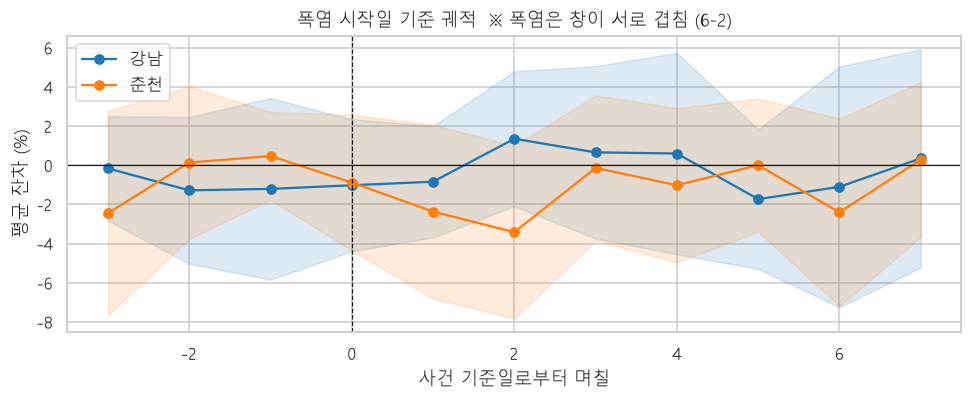

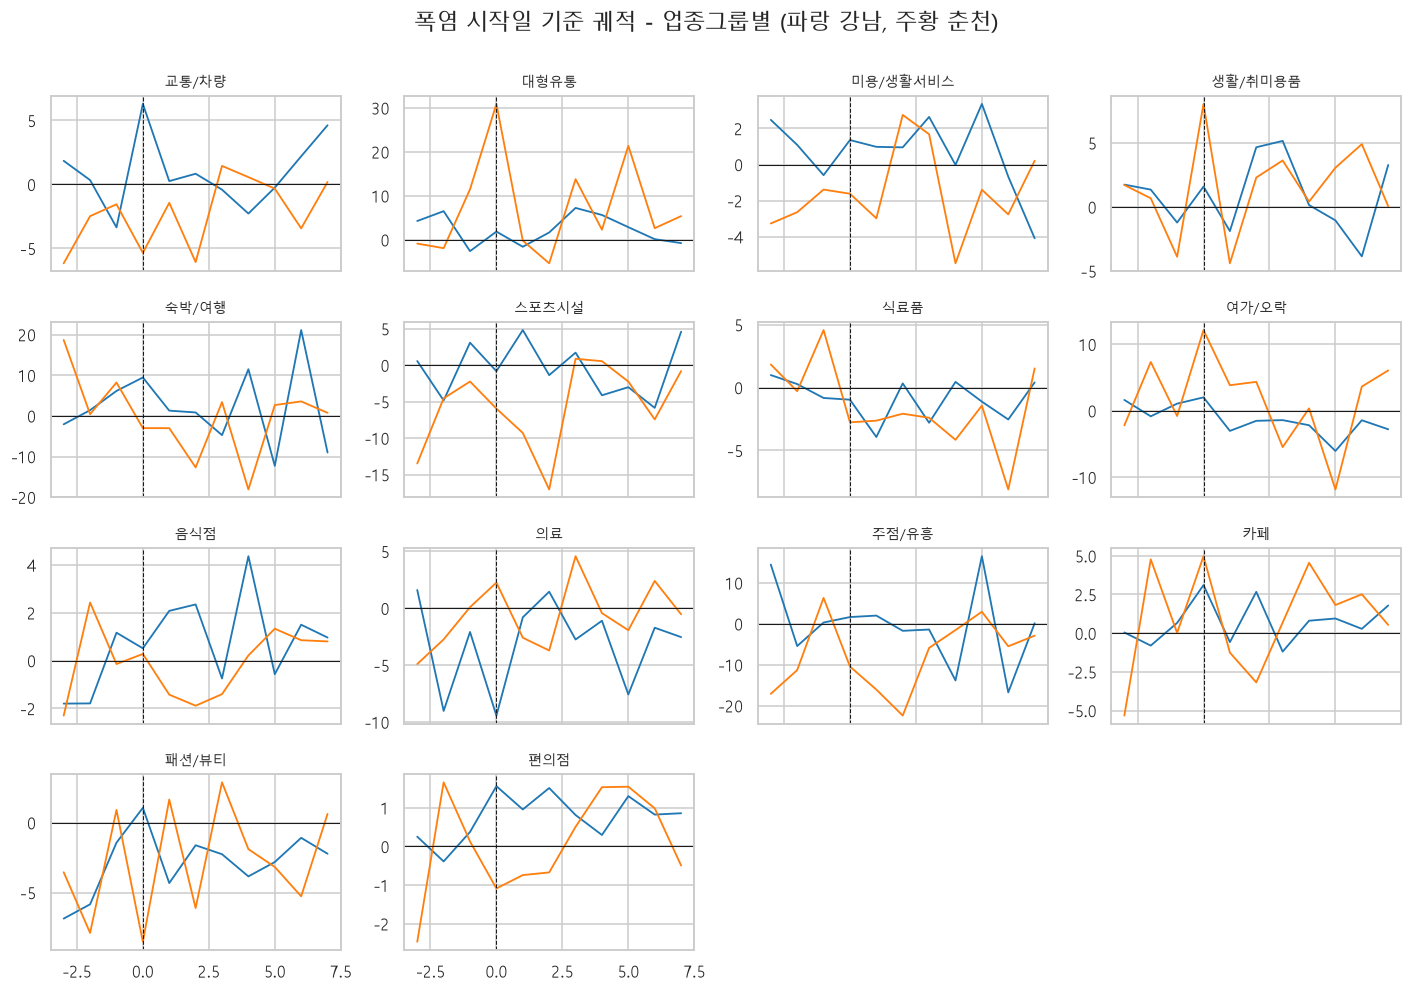

지역 합계 (평균 잔차 %, 사건 수, 표준오차)


mean         count          sem      
region     강남     춘천     강남     춘천    강남    춘천
k                                             
-3     -0.200 -2.400 10.000  9.000 1.300 2.600
-2     -1.300  0.100 10.000  9.000 1.900 1.900
-1     -1.200  0.500 10.000  9.000 2.300 1.100
 0     -1.000 -0.900 10.000 10.000 1.700 1.700
 1     -0.800 -2.400 10.000 10.000 1.400 2.200
 2      1.300 -3.400 10.000 10.000 1.700 2.200
 3      0.700 -0.100 10.000 10.000 2.200 1.900
 4      0.600 -1.000 10.000 10.000 2.600 2.000
 5     -1.700  0.000 10.000 10.000 1.800 1.700
 6     -1.100 -2.400 10.000 10.000 3.100 2.400
 7      0.300  0.300 10.000 10.000 2.800 2.000

k = 0 업종그룹별 (%)


region,강남,춘천
industry_group,,
교통/차량,6.300,-5.400
대형유통,1.900,30.900
미용/생활서비스,1.400,-1.600
생활/취미용품,1.600,8.000
숙박/여행,9.400,-3.000
스포츠시설,-0.800,-6.000
식료품,-1.000,-2.800
여가/오락,2.000,12.100
음식점,0.500,0.300


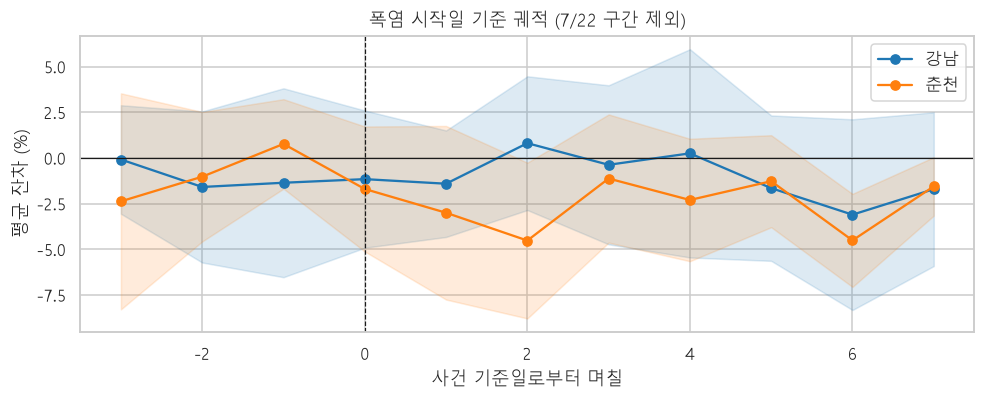

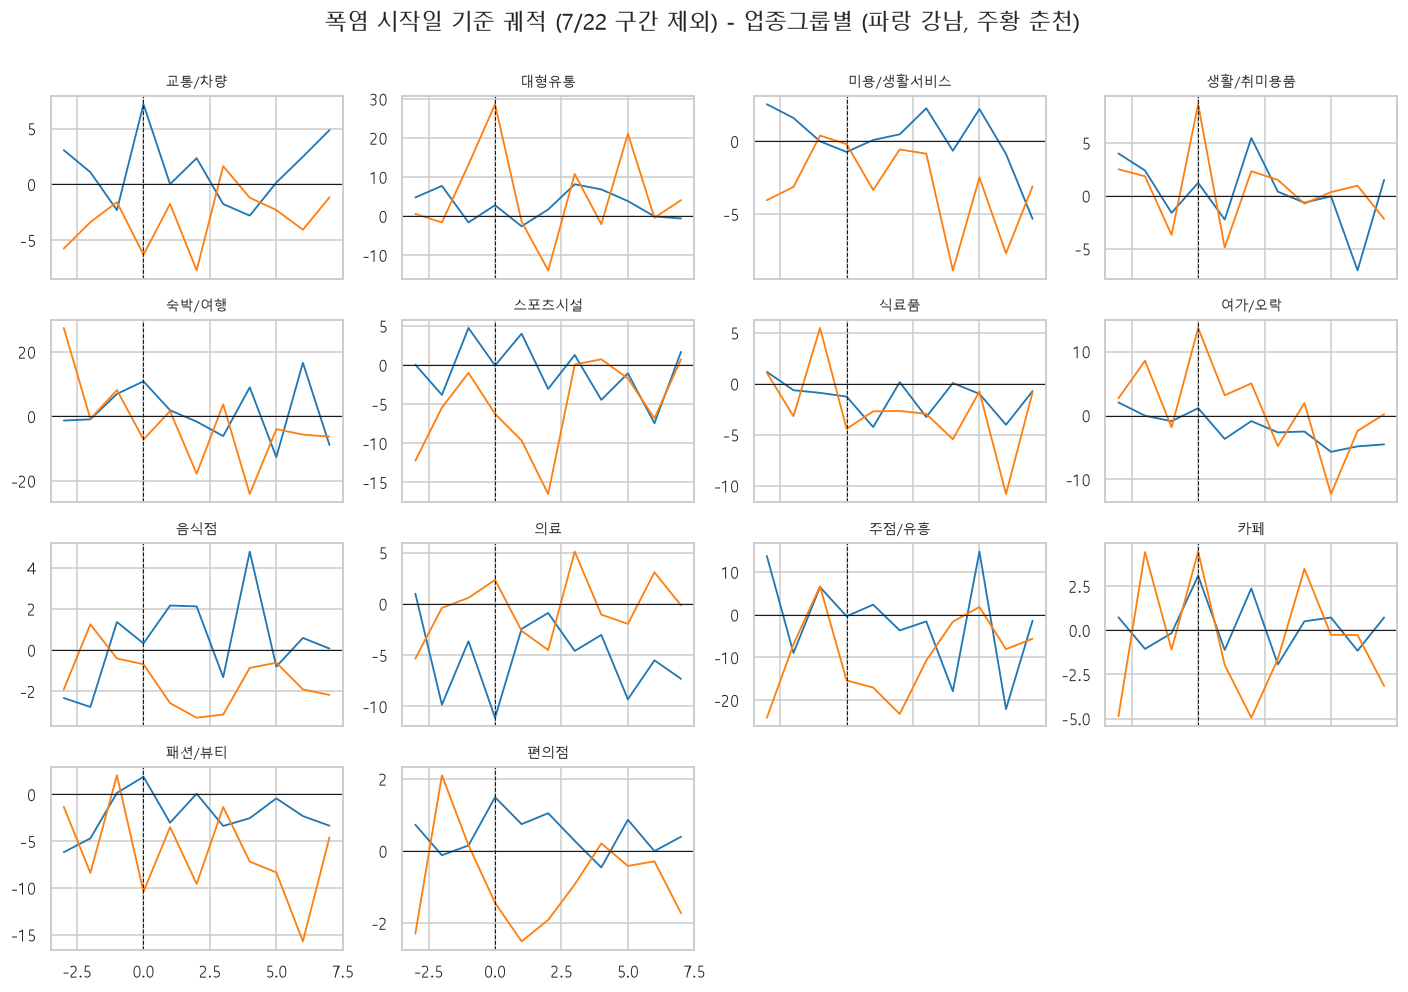

region,강남,춘천
k,,
-3,-0.100,-2.400
-2,-1.600,-1.000
-1,-1.400,0.800
0,-1.200,-1.700
1,-1.400,-3.000
2,0.800,-4.500
3,-0.400,-1.100
4,0.300,-2.300
5,-1.700,-1.300


-> 7/22 구간을 빼도 결론은 같다. 폭염 시작일에 매출이 눌리지 않는다.


In [27]:
def 궤적표(ev, 기준='start', 뺄구간=None):
    # 사건마다 k = WINDOW[0] ~ WINDOW[1] 에 해당하는 날짜를 만들어 잔차를 붙인다.
    e = events[events['event'].eq(ev)]
    if 뺄구간 is not None:
        e = e[~e['start'].isin(뺄구간)]
    행 = []
    for _, x in e.iterrows():
        for k in range(WINDOW[0], WINDOW[1] + 1):
            행.append({'region': x['region'], 'spell_id': x['spell_id'], 'k': k,
                       'date': x[기준] + pd.Timedelta(days=k)})
    긴표 = pd.DataFrame(행)
    return 긴표.merge(resid_ev, on=['date', 'region'])


def 궤적요약(긴표):
    t = (긴표.groupby(['region', 'industry_group', 'k'], observed=True)['resid']
         .agg(['mean', 'count', 'sem']).reset_index())
    t[['mean', 'sem']] *= 100
    return t


def 궤적그림(t, 제목, 겹침메모=''):
    fig, ax = plt.subplots(figsize=(9, 3.8))
    for r in REGIONS:
        g = t[t['region'].eq(r) & t['industry_group'].eq('(지역 합계)')].sort_values('k')
        ax.plot(g['k'], g['mean'], 'o-', color=REGION_COLOR[r], label=r)
        ax.fill_between(g['k'], g['mean'] - 2 * g['sem'], g['mean'] + 2 * g['sem'],
                        color=REGION_COLOR[r], alpha=0.15)
    ax.axhline(0, color='k', lw=0.8); ax.axvline(0, ls='--', color='k', lw=0.8)
    ax.set(xlabel='사건 기준일로부터 며칠', ylabel='평균 잔차 (%)', title=제목 + 겹침메모)
    ax.legend()
    plt.tight_layout(); plt.show()

    fig, axes = plt.subplots(4, 4, figsize=(13, 9), sharex=True)
    for ax, g in zip(axes.ravel(), GROUPS):
        for r in REGIONS:
            s = t[t['region'].eq(r) & t['industry_group'].eq(g)].sort_values('k')
            ax.plot(s['k'], s['mean'], color=REGION_COLOR[r], lw=1.2)
        ax.axhline(0, color='k', lw=0.7); ax.axvline(0, ls='--', color='k', lw=0.7)
        ax.set_title(g, fontsize=9)
    for ax in axes.ravel()[len(GROUPS):]:
        ax.axis('off')
    fig.suptitle(제목 + ' - 업종그룹별 (파랑 강남, 주황 춘천)', y=1.0)
    plt.tight_layout(); plt.show()


heat_traj = 궤적요약(궤적표('heat33'))
궤적그림(heat_traj, '폭염 시작일 기준 궤적', '  ※ 폭염은 창이 서로 겹침 (6-2)')

print('지역 합계 (평균 잔차 %, 사건 수, 표준오차)')
display(heat_traj[heat_traj['industry_group'].eq('(지역 합계)')]
        .pivot(index='k', columns='region', values=['mean', 'count', 'sem']).round(1))
print('k = 0 업종그룹별 (%)')
display(heat_traj[heat_traj['k'].eq(0) & heat_traj['industry_group'].ne('(지역 합계)')]
        .pivot(index='industry_group', columns='region', values='mean').round(1))

# 가장 긴 구간(7/22 시작)은 바로 앞에 큰 호우가 있었고 7월 말(월말 효과)에 걸쳐 있다. 이 구간을 뺀 평균
뺀궤적 = 궤적요약(궤적표('heat33', 뺄구간=[pd.Timestamp('2025-07-22')]))
궤적그림(뺀궤적, '폭염 시작일 기준 궤적 (7/22 구간 제외)')
display(뺀궤적[뺀궤적['industry_group'].eq('(지역 합계)')]
        .pivot(index='k', columns='region', values='mean').round(1))
print('-> 7/22 구간을 빼도 결론은 같다. 폭염 시작일에 매출이 눌리지 않는다.')

### 7-2. 호우 시작일 기준 궤적

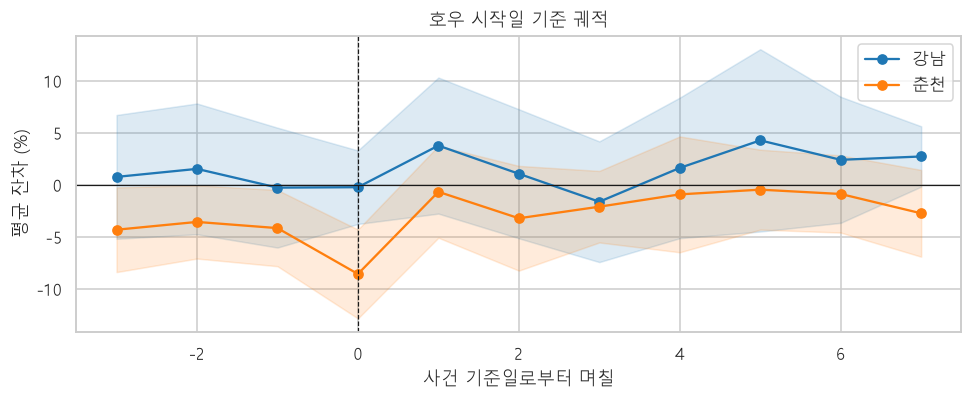

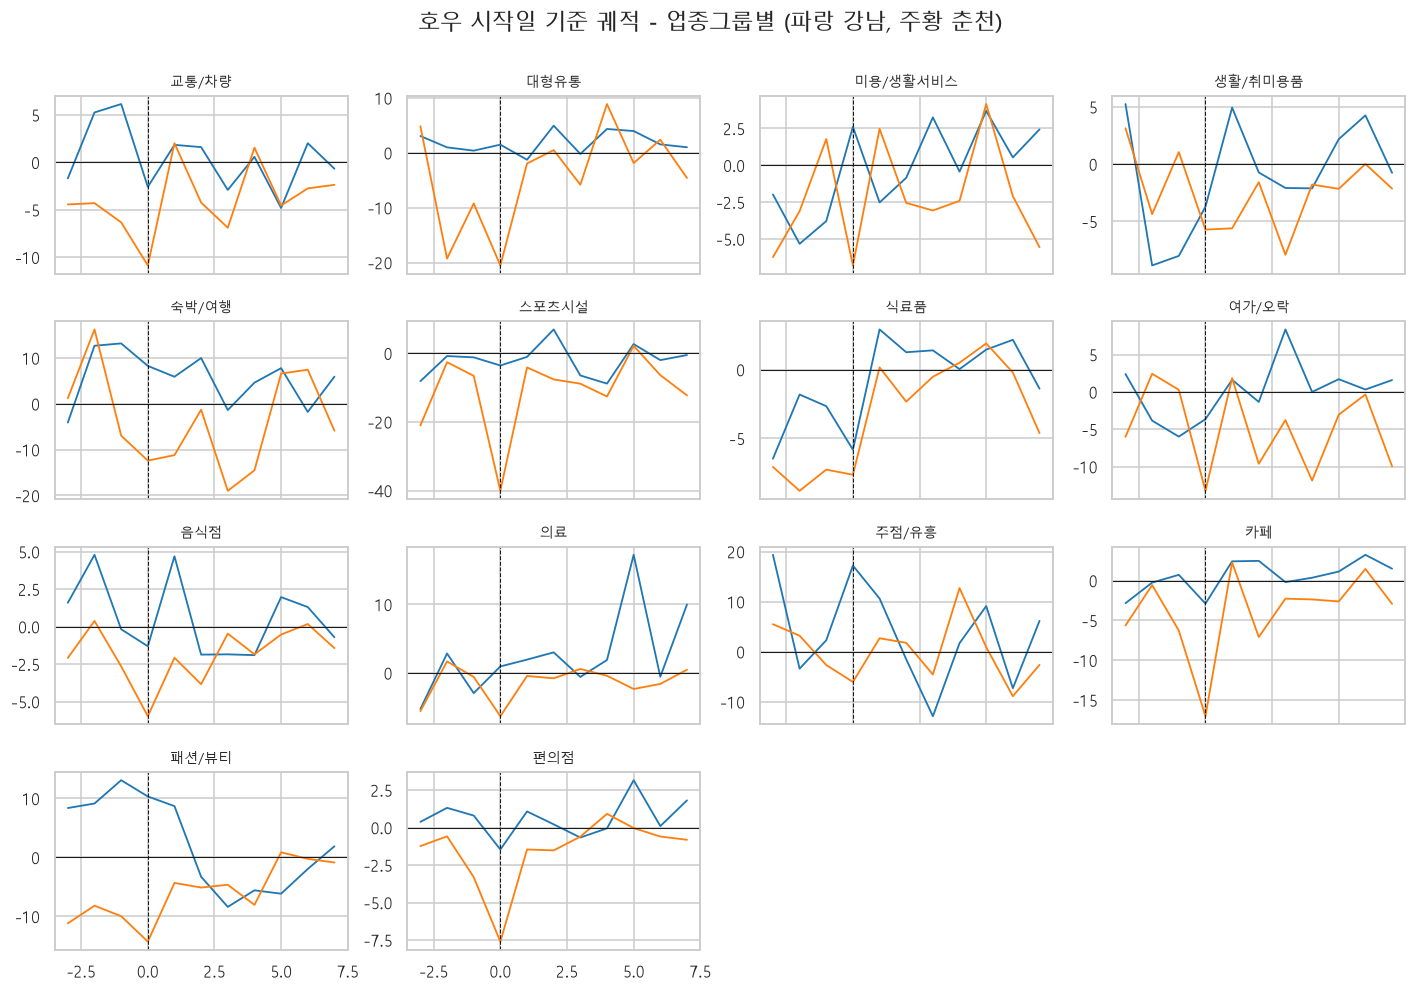

지역 합계 (평균 잔차 %, 사건 수, 표준오차)


mean        count          sem      
region     강남     춘천    강남     춘천    강남    춘천
k                                            
-3      0.800 -4.300 8.000 14.000 3.000 2.000
-2      1.500 -3.500 8.000 14.000 3.100 1.800
-1     -0.300 -4.100 8.000 14.000 2.900 1.800
 0     -0.200 -8.600 8.000 14.000 1.800 2.100
 1      3.800 -0.700 8.000 14.000 3.300 2.200
 2      1.100 -3.200 8.000 14.000 3.100 2.500
 3     -1.600 -2.100 8.000 14.000 2.900 1.700
 4      1.600 -0.900 8.000 14.000 3.400 2.800
 5      4.300 -0.400 8.000 14.000 4.400 1.900
 6      2.400 -0.900 8.000 14.000 3.000 1.900
 7      2.700 -2.700 8.000 14.000 1.500 2.100

k = 0 업종그룹별 (%)


region,강남,춘천
industry_group,,
스포츠시설,-3.600,-40.100
대형유통,1.500,-20.500
카페,-2.900,-17.000
패션/뷰티,10.300,-14.300
여가/오락,-3.600,-13.200
숙박/여행,8.300,-12.400
교통/차량,-2.600,-10.900
식료품,-5.800,-7.600
편의점,-1.500,-7.600


-> 춘천은 호우 당일에 크게 빠졌다가 하루 만에 대부분 돌아온다. 강남은 호우에 반응이 없다.
-> 춘천 k = -1도 낮은 건 호우 구간이 3 ~ 5일 간격으로 붙어 있어 전날에도 비가 온 경우가 많기 때문이다.


In [28]:
rain_traj = 궤적요약(궤적표('rain30'))
궤적그림(rain_traj, '호우 시작일 기준 궤적')

print('지역 합계 (평균 잔차 %, 사건 수, 표준오차)')
display(rain_traj[rain_traj['industry_group'].eq('(지역 합계)')]
        .pivot(index='k', columns='region', values=['mean', 'count', 'sem']).round(1))
print('k = 0 업종그룹별 (%)')
display(rain_traj[rain_traj['k'].eq(0) & rain_traj['industry_group'].ne('(지역 합계)')]
        .pivot(index='industry_group', columns='region', values='mean').round(1)
        .sort_values('춘천'))
print('-> 춘천은 호우 당일에 크게 빠졌다가 하루 만에 대부분 돌아온다. 강남은 호우에 반응이 없다.')
print('-> 춘천 k = -1도 낮은 건 호우 구간이 3 ~ 5일 간격으로 붙어 있어 전날에도 비가 온 경우가 많기 때문이다.')

### 7-3. 종료일 기준 궤적 (회복 구간)

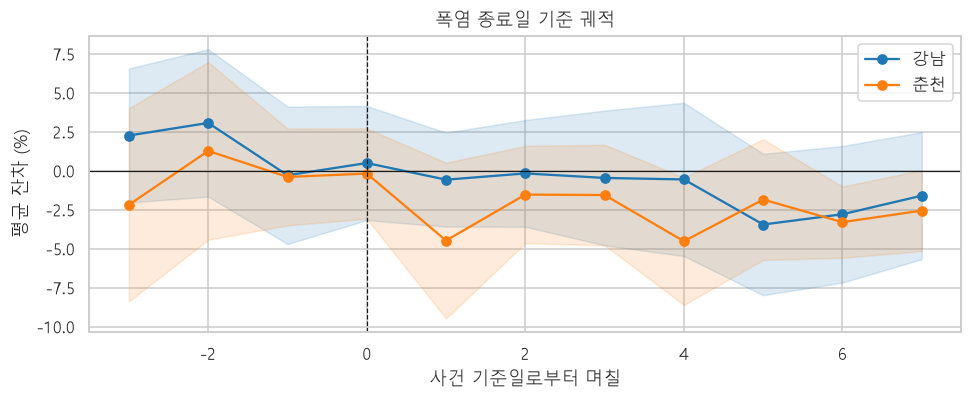

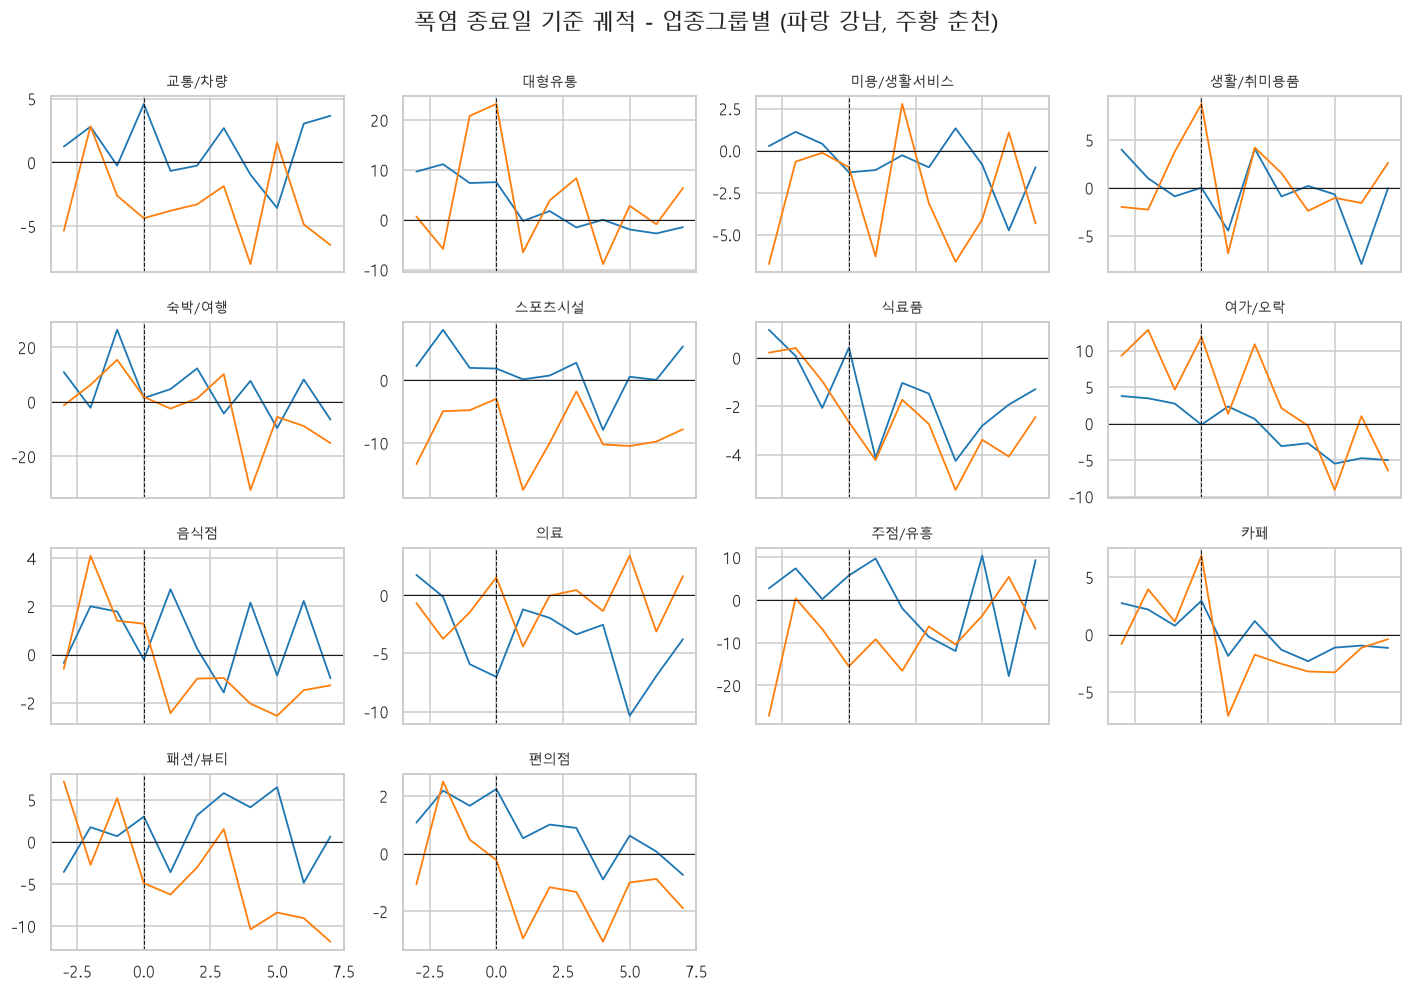

region,강남,춘천
폭염 종료일 기준 지역 합계 (%),,
-3,2.300,-2.200
-2,3.100,1.300
-1,-0.300,-0.400
0,0.500,-0.200
1,-0.600,-4.500
2,-0.200,-1.500
3,-0.500,-1.600
4,-0.600,-4.500
5,-3.500,-1.900


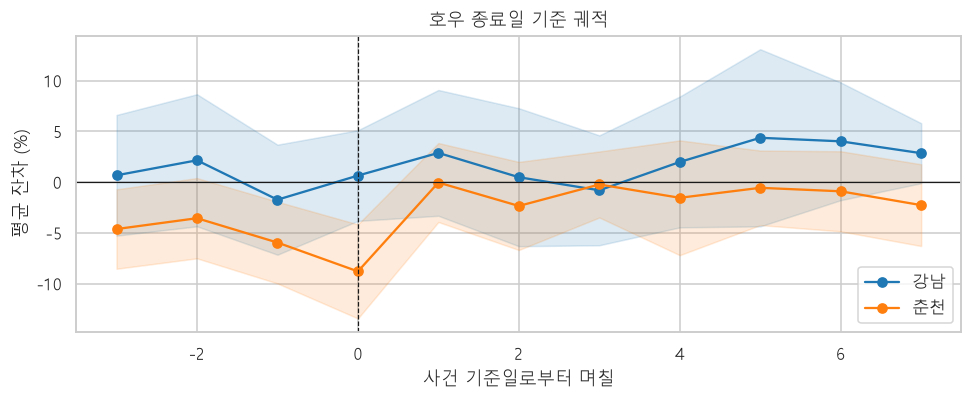

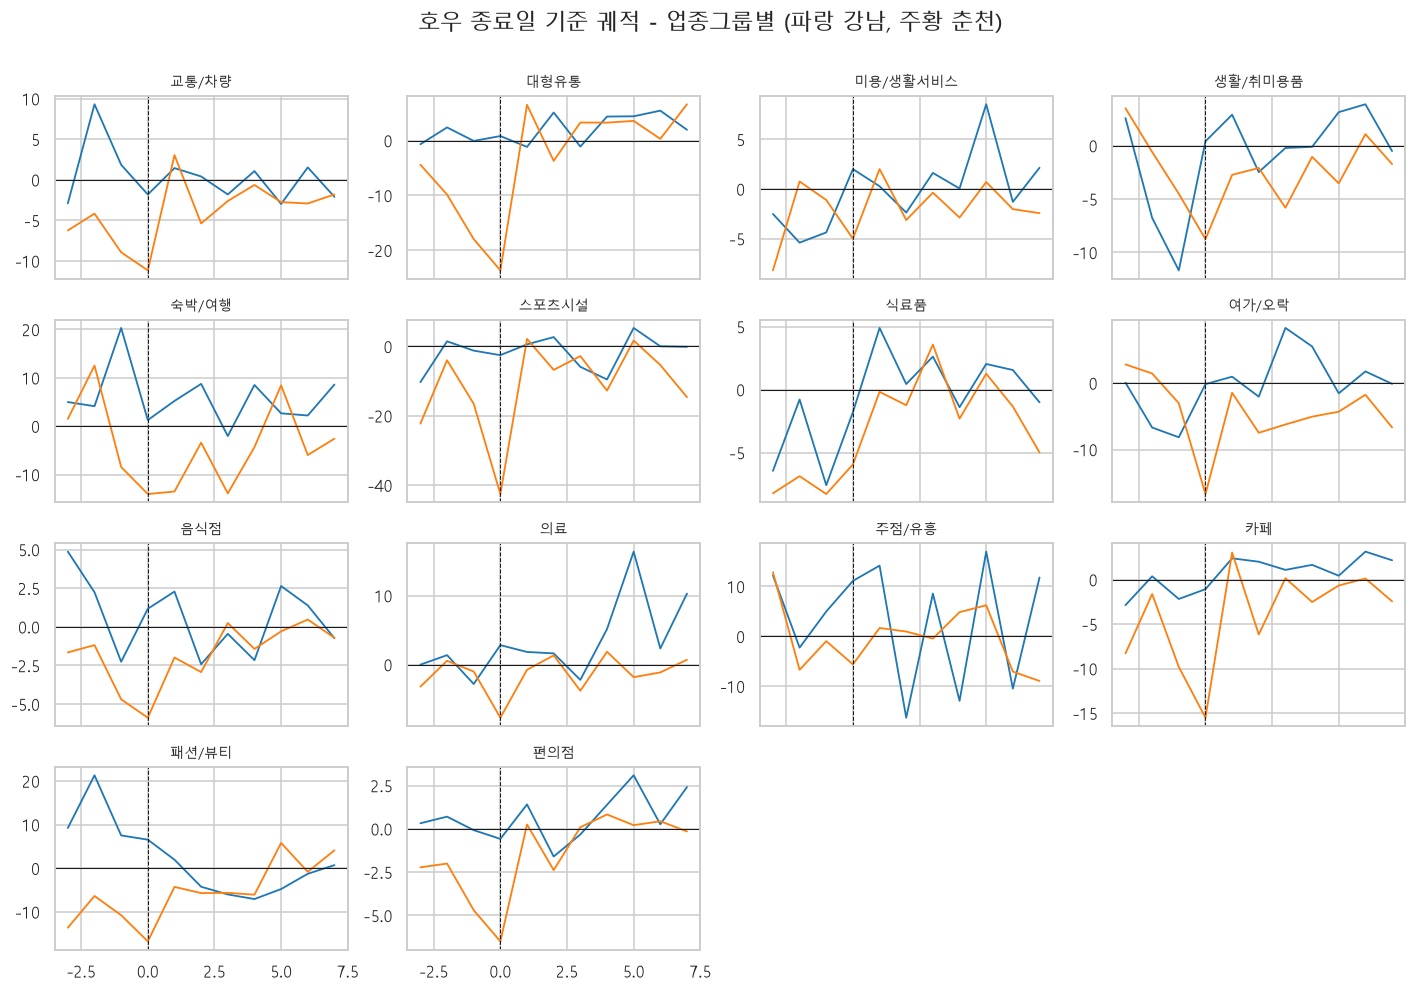

region,강남,춘천
호우 종료일 기준 지역 합계 (%),,
-3,0.700,-4.600
-2,2.100,-3.600
-1,-1.700,-6.000
0,0.600,-8.800
1,2.900,-0.000
2,0.500,-2.400
3,-0.800,-0.200
4,2.000,-1.600
5,4.400,-0.600


-> 폭염은 "중에"가 아니라 "끝난 뒤"에 춘천 매출이 조금 낮다.
-> 호우는 종료 당일까지만 낮고 다음 날 바로 0으로 돌아온다.
-> 폭염 종료 뒤가 낮은 것이 다음 폭염, 호우와 겹친 탓인지는 7-4에서 확인한다.


In [29]:
# 폭염은 12일짜리 구간도 있어서 시작일 기준으로는 "끝난 뒤"가 섞인다. 회복을 보려면 종료일을 0으로 맞춘다.
for ev, 이름 in [('heat33', '폭염'), ('rain30', '호우')]:
    t = 궤적요약(궤적표(ev, 기준='end'))
    궤적그림(t, f'{이름} 종료일 기준 궤적')
    display(t[t['industry_group'].eq('(지역 합계)')]
            .pivot(index='k', columns='region', values='mean').round(1)
            .rename_axis(f'{이름} 종료일 기준 지역 합계 (%)'))
    if ev == 'heat33':
        heat_end = t
    else:
        rain_end = t
print('-> 폭염은 "중에"가 아니라 "끝난 뒤"에 춘천 매출이 조금 낮다.')
print('-> 호우는 종료 당일까지만 낮고 다음 날 바로 0으로 돌아온다.')
print('-> 폭염 종료 뒤가 낮은 것이 다음 폭염, 호우와 겹친 탓인지는 7-4에서 확인한다.')

### 7-4. 미뤄진 소비가 몰리는가 (pent-up 검사)

In [30]:
# 사건 하나마다 세 구간(+ 8장에서 쓸 두 구간)의 평균 잔차를 구한다.
구간정의 = {'pre':      ('start', -7, -1),   # 시작 7일 전 ~ 1일 전
            'during':   ('start',  0,  0),   # 시작 ~ 종료 (끝은 아래에서 end로 바꿔 씀)
            'post1_3':  ('end',    1,  3),   # 종료 후 1 ~ 3일
            'post4_W':  ('end',    4, WINDOW[1]),
            'post1_7':  ('end',    1,  7)}


def 사건별잔차():
    행 = []
    for _, x in events.iterrows():
        for 이름, (기준, a, b) in 구간정의.items():
            if 이름 == 'during':
                lo, hi = x['start'], x['end']
            else:
                lo = x[기준] + pd.Timedelta(days=a)
                hi = x[기준] + pd.Timedelta(days=b)
            for d in pd.date_range(lo, hi):
                행.append({'region': x['region'], 'event': x['event'], 'spell_id': x['spell_id'],
                           '구간': 이름, 'date': d})
    긴표 = pd.DataFrame(행).merge(resid_ev, on=['date', 'region'])
    return (긴표.groupby(['region', 'event', 'spell_id', 'industry_group', '구간'], observed=True)['resid']
            .mean().unstack('구간').reset_index())


ev_stats = 사건별잔차()
print(f'ev_stats {len(ev_stats):,}행 (사건 x 업종그룹)')
display(ev_stats.head(3))

# post1_7 평균이 0과 다른가 (사건들끼리 t검정)
행 = []
for (r, ev, g), s in ev_stats.groupby(['region', 'event', 'industry_group'], observed=True):
    v = s['post1_7'].dropna()
    if len(v) < 3:
        continue
    행.append({'지역': r, '이벤트': EV_NAME[ev], '업종그룹': g, '사건 수': len(v),
               'during(%)': s['during'].mean() * 100,
               'post1_7(%)': v.mean() * 100, 'p': stats.ttest_1samp(v, 0).pvalue})
pent = pd.DataFrame(행)

print('지역 합계')
display(pent[pent['업종그룹'].eq('(지역 합계)')].drop(columns='업종그룹')
        .set_index(['이벤트', '지역']).round(3))
print('1순위 업종그룹')
display(pent[pent['업종그룹'].isin(PRIORITY_GROUPS)]
        .pivot(index='업종그룹', columns=['이벤트', '지역'], values='post1_7(%)').round(1))
print('-> 호우: 두 지역 모두 종료 뒤 1주일이 0 근처다. 반등(pent-up)이 없다.')
print('   비 온 날 못 쓴 돈은 다시 돌아오지 않는다 = 순손실이다.')
print('-> 폭염: 춘천만 종료 뒤 1주일이 약간 낮다. 다만 창이 겹쳐 다음 폭염의 영향일 수 있다.')

ev_stats 630행 (사건 x 업종그룹)


구간,region,event,spell_id,industry_group,during,post1_3,post1_7,post4_W,pre
0,강남,heat33,1,(지역 합계),0.020,0.027,-0.012,-0.041,-0.008
1,강남,heat33,1,교통/차량,-0.007,-0.001,-0.060,-0.105,0.052
2,강남,heat33,1,대형유통,0.199,0.012,0.003,-0.004,0.027


지역 합계


,,사건 수,during(%),post1_7(%),p
이벤트,지역,,,,
폭염,강남,10,0.217,-1.376,0.363
호우,강남,8,0.212,2.246,0.374
폭염,춘천,10,0.133,-2.831,0.004
호우,춘천,14,-8.740,-1.136,0.469


1순위 업종그룹


이벤트,폭염,호우,폭염,호우
지역,강남,강남,춘천,춘천
업종그룹,,,,
식료품,-2.400,1.300,-3.400,-0.700
음식점,0.600,0.100,-1.700,-0.900
카페,-1.100,1.800,-2.800,-1.200
편의점,0.200,0.900,-1.700,-0.100


-> 호우: 두 지역 모두 종료 뒤 1주일이 0 근처다. 반등(pent-up)이 없다.
   비 온 날 못 쓴 돈은 다시 돌아오지 않는다 = 순손실이다.
-> 폭염: 춘천만 종료 뒤 1주일이 약간 낮다. 다만 창이 겹쳐 다음 폭염의 영향일 수 있다.


### 7-5. 여름이 끝나는 전환 한 번 보기

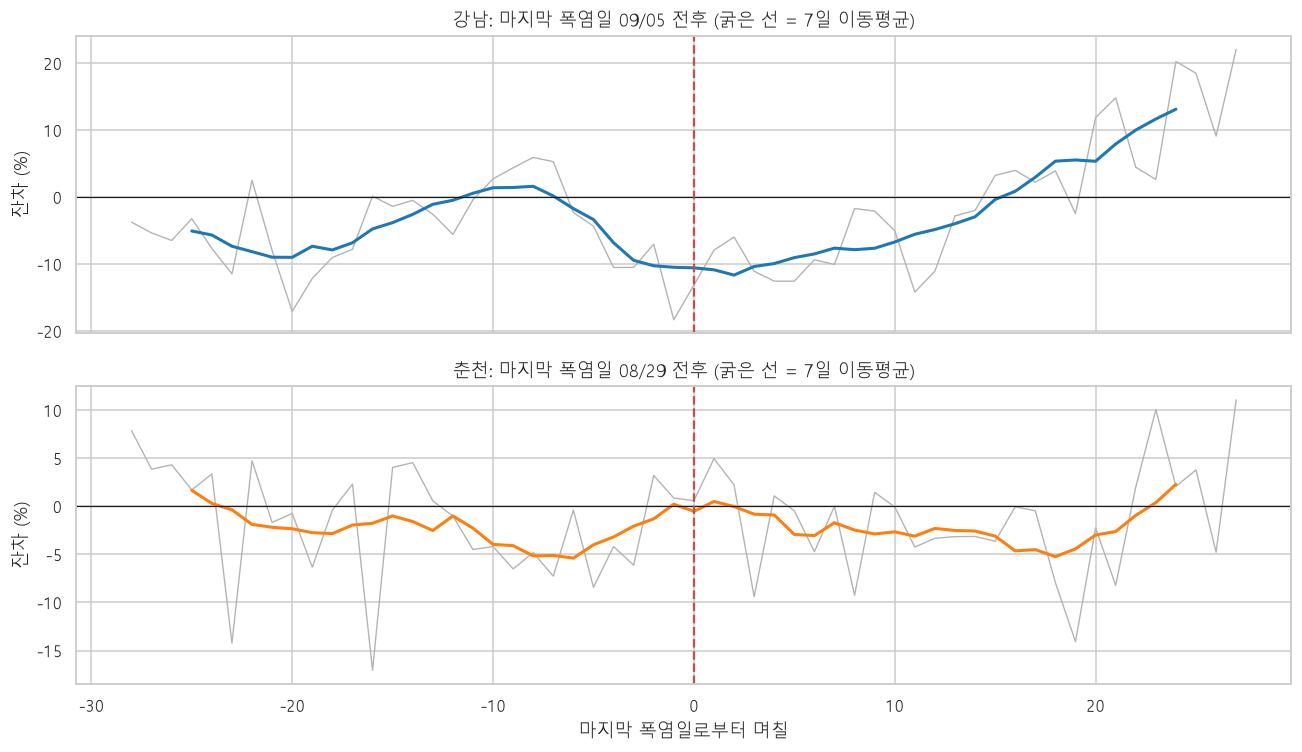

,마지막 폭염일,전 3주(%),후 3주(%),차이(%p)
지역,,,,
강남,09/05,-4.900,-3.400,1.600
춘천,08/29,-2.700,-3.100,-0.400


-> 여름이 끝났다고 매출이 뚜렷하게 오르지 않는다. 폭염이 매출을 누르고 있었다는 증거가 없다 (3장과 같은 결론).


In [31]:
# 폭염 구간들이 겹쳐 있으니, 대안으로 "마지막 폭염일" 전후 3주를 비교한다.
# 주의: 월 더미가 있으면 8월 -> 9월 변화를 월 더미가 먹어 버린다. 이 분석만 월 더미 없는 기준선을 쓴다.
식 = 'y ~ C(dow) + is_holiday + is_chuseok_break + C(chuseok_day)'
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
행 = []
for ax, r in zip(axes, REGIONS):
    q = total[total['region'].eq(r)].copy()
    q['resid'] = smf.ols(식, data=q).fit().resid * 100
    마지막 = q.loc[q['heat33'], 'date'].max()
    q['k'] = (q['date'] - 마지막).dt.days
    g = q[q['k'].between(-28, 27)].sort_values('k')
    ax.plot(g['k'], g['resid'], color='0.7', lw=0.9)
    ax.plot(g['k'], g['resid'].rolling(7, center=True).mean(), color=REGION_COLOR[r], lw=2)
    ax.axhline(0, color='k', lw=0.8); ax.axvline(0, ls='--', color='r')
    ax.set(ylabel='잔차 (%)', title=f'{r}: 마지막 폭염일 {마지막:%m/%d} 전후 (굵은 선 = 7일 이동평균)')
    행.append({'지역': r, '마지막 폭염일': f'{마지막:%m/%d}',
               '전 3주(%)': g.loc[g['k'].between(-20, 0), 'resid'].mean(),
               '후 3주(%)': g.loc[g['k'].between(1, 21), 'resid'].mean()})
axes[1].set_xlabel('마지막 폭염일로부터 며칠')
plt.tight_layout(); plt.show()

전후 = pd.DataFrame(행).set_index('지역')
전후['차이(%p)'] = 전후['후 3주(%)'] - 전후['전 3주(%)']
display(전후.round(1))
print('-> 여름이 끝났다고 매출이 뚜렷하게 오르지 않는다. 폭염이 매출을 누르고 있었다는 증거가 없다 (3장과 같은 결론).')

### 7장 정리
- **본 것**: 폭염과 호우의 시작일, 종료일을 0으로 맞춘 궤적을 그리고, 사건마다 pre / during / post 구간 평균으로 반등(pent-up) 여부를 t검정했다.
- **나온 것**: 호우 당일 춘천 -8.6%(표준오차 2.1) -> 다음 날 -0.7%로 **하루 만에 돌아온다**. 그런데 종료 후 1주일 평균은 -1.1%(p 0.47)로 **반등이 없다**.
  폭염은 시작일에도(-1.0%, -0.9%) 종료 후에도 뚜렷한 눌림이 없고, 마지막 폭염일 전후 3주 비교에서도 매출이 오르지 않았다(강남 -4.9% -> -3.4%, 춘천 -2.7% -> -3.1%).
- **시사점**: 호우는 **순손실**이다. "하루 만에 회복하지만 잃은 매출은 돌아오지 않는다"가 이 프로젝트의 핵심 문장이다.
  07번 5-4는 "호우 다음 날 수준이 돌아오므로 시점 이동"으로 적었지만, 여기서는 **돌아온 것은 수준이고 잃은 양은 돌아오지 않았다**는 점을 구분해 순손실로 본다. 07번 문장을 이 결론으로 고쳐 쓴다.
  [추론] 춘천 폭염 종료 뒤 1주가 -2.8%(p 0.004)로 약간 낮은데, 창이 겹쳐 다음 폭염, 호우가 섞였을 가능성이 크다. 폭염 탓이라고 단정할 수 없다.

## 8. 회복 유형과 유동 vs 소비
7장의 궤적을 업종그룹마다 한 단어(즉시회복 / 지연회복 / 미회복)로 요약하고, 지하철 승하차를 겹쳐 "사람이 안 나온 것"과 "나와서 안 쓴 것"을 나눈다.

### 8-1. 회복 유형 규칙 정하기
아래는 잠정 규칙이다. `B = RECOVERY_BAND` (기본 0.03, 약 3%). 사건마다 구한 구간 평균을 사건들끼리 다시 평균 낸 값으로 판정한다.

| 순서 | 조건 | 유형 |
|---|---|---|
| 1 | 충격 중(during) 평균 잔차 > -B | 충격 없음 |
| 2 | 종료 후 1~3일(post1_3) 평균 ≥ -B | 즉시회복 |
| 3 | 종료 후 4일 ~ WINDOW[1]일(post4_W) 평균 ≥ -B | 지연회복 |
| 4 | 둘 다 아님 | 미회복 |

추가 표시: 종료 후 1~7일(post1_7) 평균 > +B 이면 "반등"(pent-up) 표시.
기본 창 (-3, 7)이면 post4_W = 종료 후 4~7일이다. 창이 짧아서 "지연"과 "미회복"을 가르는 기간이 짧다는 점을 기억한다.

In [32]:
# 사건마다 구한 구간 평균을, 사건들끼리 다시 평균 낸 값으로 판정한다.
구간열 = ['pre', 'during', 'post1_3', 'post4_W', 'post1_7']
agg = (ev_stats.groupby(['region', 'event', 'industry_group'], observed=True)[구간열]
       .mean().reset_index())
agg['이벤트'] = agg['event'].map(EV_NAME)


def 회복유형(r):
    B = RECOVERY_BAND
    if r['during'] > -B:
        return '충격 없음'
    if r['post1_3'] >= -B:
        return '즉시회복'
    if r['post4_W'] >= -B:
        return '지연회복'
    return '미회복'


agg['유형'] = agg.apply(회복유형, axis=1)
agg['반등'] = agg['post1_7'] > RECOVERY_BAND      # pent-up 표시

print('지역 합계 (구간 평균 잔차 %)')
display(agg[agg['industry_group'].eq('(지역 합계)')]
        .set_index(['이벤트', 'region'])[구간열 + ['유형', '반등']]
        .assign(**{c: lambda d, c=c: (d[c] * 100).round(1) for c in 구간열}))
print(f'-> RECOVERY_BAND = {RECOVERY_BAND} (약 {RECOVERY_BAND * 100:.0f}%). 6-4에서 본 평상일 하루 흔들림(7 ~ 9%)보다 좁다.')
print('   좁게 잡으면 "충격 없음"이 줄고 "미회복"이 늘어난다. 폭을 바꿔 보고 결과가 뒤집히는지 확인할 것.')

지역 합계 (구간 평균 잔차 %)


,구간,pre,during,post1_3,post4_W,post1_7,유형,반등
이벤트,region,,,,,,,
폭염,강남,0.300,0.200,-0.400,-2.100,-1.400,충격 없음,False
호우,강남,0.400,0.200,0.800,3.300,2.200,충격 없음,False
폭염,춘천,-0.800,0.100,-2.500,-3.100,-2.800,충격 없음,False
호우,춘천,-2.500,-8.700,-0.900,-1.300,-1.100,즉시회복,False


-> RECOVERY_BAND = 0.03 (약 3%). 6-4에서 본 평상일 하루 흔들림(7 ~ 9%)보다 좁다.
   좁게 잡으면 "충격 없음"이 줄고 "미회복"이 늘어난다. 폭을 바꿔 보고 결과가 뒤집히는지 확인할 것.


**결정**: 회복 유형 규칙과 `RECOVERY_BAND` 를 정한다. 6-4의 평상일 잔차 표준편차(소음 크기)를 보고, 폭이 너무 좁지 않은지 확인한다.

- 결정: **`RECOVERY_BAND = 0.03` 유지**, 판정 순서는 충격 없음 -> 즉시회복 -> 지연회복 -> 미회복 그대로.
- 이유: 6-4에서 본 하루 흔들림은 7 ~ 9%지만, 판정에 쓰는 값은 사건 10 ~ 14개를 평균 낸 값이라 표준오차가 1.7 ~ 2.6%p로 줄어든다. 3%는 그 표준오차의 약 1.5배라 너무 좁지 않다.
  [추론] 폭을 5%로 넓히면 춘천 호우의 지연회복 3개(생활/취미용품, 숙박/여행, 패션/뷰티)가 즉시회복으로 바뀔 가능성이 크다. 보고서에 쓰기 전에 폭을 바꿔 한 번 더 돌려 확인한다(9-4).

### 8-2. 업종그룹별 회복 유형표

유형 개수 (업종그룹 14개)


유형          미회복  즉시회복  지연회복  충격 없음
이벤트 region                        
폭염  강남        0     1     0     13
    춘천        2     1     0     11
호우  강남        0     2     0     12
    춘천        1    10     3      0

폭염


,강남 유형,춘천 유형,강남 충격(%),춘천 충격(%)
industry_group,,,,
교통/차량,충격 없음,즉시회복,4.900,-3.900
대형유통,충격 없음,충격 없음,5.800,25.300
미용/생활서비스,충격 없음,충격 없음,-0.500,-0.000
생활/취미용품,충격 없음,충격 없음,2.300,10.500
숙박/여행,충격 없음,충격 없음,3.100,-0.300
스포츠시설,충격 없음,미회복,3.000,-4.900
식료품,충격 없음,충격 없음,-0.700,-2.700
여가/오락,충격 없음,충격 없음,-0.000,14.600
음식점,충격 없음,충격 없음,0.900,1.800


호우


,강남 유형,춘천 유형,강남 충격(%),춘천 충격(%)
industry_group,,,,
교통/차량,충격 없음,즉시회복,-2.200,-11.000
대형유통,충격 없음,즉시회복,1.200,-21.800
미용/생활서비스,충격 없음,즉시회복,2.300,-5.700
생활/취미용품,충격 없음,지연회복,-1.700,-7.900
숙박/여행,충격 없음,지연회복,4.800,-14.700
스포츠시설,즉시회복,즉시회복,-3.000,-40.600
식료품,즉시회복,즉시회복,-3.800,-7.000
여가/오락,충격 없음,미회복,-1.900,-14.900
음식점,충격 없음,즉시회복,-0.100,-6.000


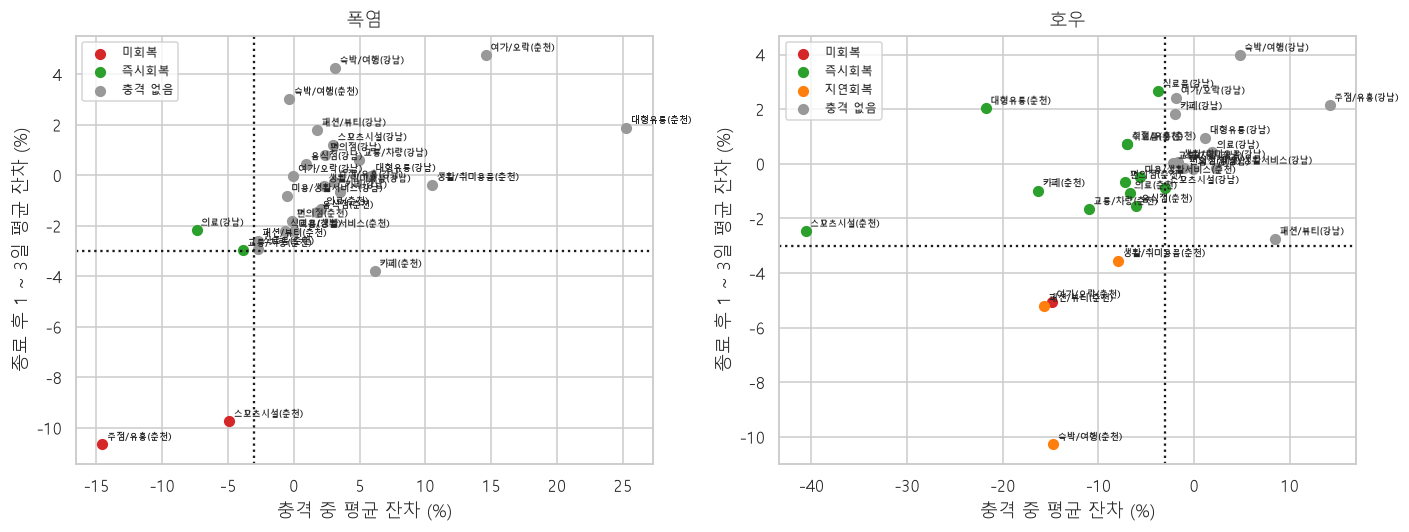

반등(pent-up) 표시가 붙은 칸


구간,이벤트,region,industry_group,during,post1_7,유형
20,호우,강남,숙박/여행,4.800,4.800,충격 없음
25,호우,강남,의료,1.900,5.100,충격 없음


-> 춘천에서 늦게 돌아오는 업종은 외지인 의존도가 높은 여가, 숙박 쪽이다 (5-2와 연결).
-> 폭염의 "미회복"은 pre(폭염 전)부터 이미 낮았던 업종인지 같이 봐야 한다. 아래 pre 열 확인.


구간,이벤트,region,industry_group,pre,during,post1_3,post4_W
36,폭염,춘천,스포츠시설,-12.700,-4.900,-9.700,-9.600
41,폭염,춘천,주점/유흥,-7.400,-14.500,-10.700,-3.800
53,호우,춘천,여가/오락,-1.200,-14.900,-5.100,-4.500


In [33]:
그룹만 = agg[agg['industry_group'].ne('(지역 합계)')]

print('유형 개수 (업종그룹 14개)')
display(그룹만.groupby(['이벤트', 'region'])['유형'].value_counts().unstack(fill_value=0))

for 이름 in ['폭염', '호우']:
    t = 그룹만[그룹만['이벤트'].eq(이름)]
    표 = t.pivot(index='industry_group', columns='region', values='유형')
    충격 = (t.pivot(index='industry_group', columns='region', values='during') * 100).round(1)
    표.columns = [f'{c} 유형' for c in 표.columns]
    충격.columns = [f'{c} 충격(%)' for c in 충격.columns]
    print(f'{이름}')
    display(표.join(충격)[sorted(표.columns) + sorted(충격.columns)])

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
색 = {'충격 없음': '0.6', '즉시회복': 'tab:green', '지연회복': 'tab:orange', '미회복': 'tab:red'}
for ax, 이름 in zip(axes, ['폭염', '호우']):
    t = 그룹만[그룹만['이벤트'].eq(이름)]
    for 유형, s in t.groupby('유형'):
        ax.scatter(s['during'] * 100, s['post1_3'] * 100, color=색[유형], label=유형, s=40)
    for _, x in t.iterrows():
        ax.annotate(f'{x["industry_group"]}({x["region"]})', (x['during'] * 100, x['post1_3'] * 100),
                    fontsize=6, xytext=(3, 3), textcoords='offset points')
    ax.axvline(-RECOVERY_BAND * 100, ls=':', color='k'); ax.axhline(-RECOVERY_BAND * 100, ls=':', color='k')
    ax.set(xlabel='충격 중 평균 잔차 (%)', ylabel='종료 후 1 ~ 3일 평균 잔차 (%)', title=f'{이름}')
    ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

print('반등(pent-up) 표시가 붙은 칸')
display(그룹만[그룹만['반등']][['이벤트', 'region', 'industry_group', 'during', 'post1_7', '유형']]
        .assign(during=lambda d: (d['during'] * 100).round(1), post1_7=lambda d: (d['post1_7'] * 100).round(1)))
print('-> 춘천에서 늦게 돌아오는 업종은 외지인 의존도가 높은 여가, 숙박 쪽이다 (5-2와 연결).')
print('-> 폭염의 "미회복"은 pre(폭염 전)부터 이미 낮았던 업종인지 같이 봐야 한다. 아래 pre 열 확인.')
display(그룹만[그룹만['유형'].eq('미회복')][['이벤트', 'region', 'industry_group', 'pre', 'during', 'post1_3', 'post4_W']]
        .assign(**{c: lambda d, c=c: (d[c] * 100).round(1) for c in ['pre', 'during', 'post1_3', 'post4_W']}))

### 8-3. 지하철 궤적 겹치기 (유동 vs 소비)

sub 368행  (2025-07-01 ~ 2025-12-31)


region,강남,춘천
하루 평균 승하차,"1,229,861.000","11,864.000"


강남 지하철 평상일 기준선 R2 0.985
춘천 지하철 평상일 기준선 R2 0.681


지역,강남,춘천
지하철 효과 (%),,
열대야,0.600,1.200
폭염,0.600,2.400
호우,0.300,-15.800


지역,강남,춘천
p값,,
열대야,0.643,0.518
폭염,0.527,0.260
호우,0.817,0.000


카드(3-3 지역 합계)와 비교


region,강남,춘천
카드 효과 (%),,
heat33,2.700,1.700
rain30,-0.600,-8.700
tropical,1.500,3.300


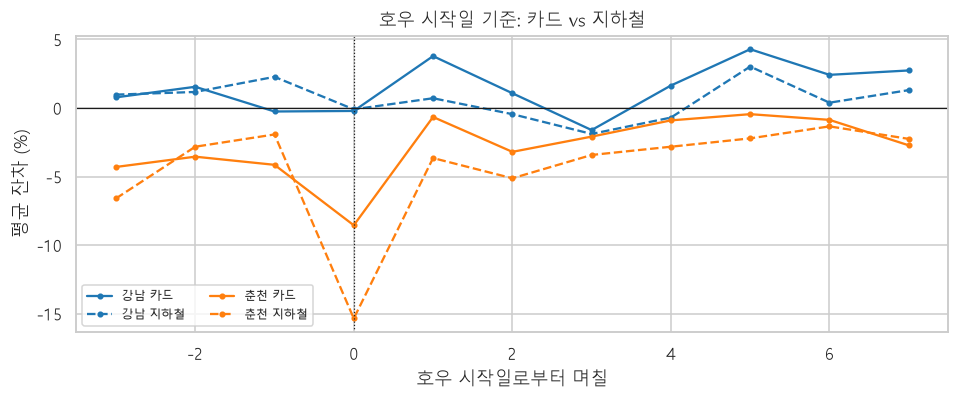

region              강남             춘천        
industry_group (지역 합계)  (지하철) (지역 합계)   (지하철)
k                                            
-3               0.800  1.000  -4.300  -6.600
-2               1.500  1.200  -3.500  -2.800
-1              -0.300  2.300  -4.100  -1.900
 0              -0.200 -0.100  -8.600 -15.300
 1               3.800  0.700  -0.700  -3.600
 2               1.100 -0.400  -3.200  -5.100
 3              -1.600 -1.900  -2.100  -3.400
 4               1.600 -0.700  -0.900  -2.800
 5               4.300  3.000  -0.400  -2.200
 6               2.400  0.400  -0.900  -1.300
 7               2.700  1.300  -2.700  -2.300

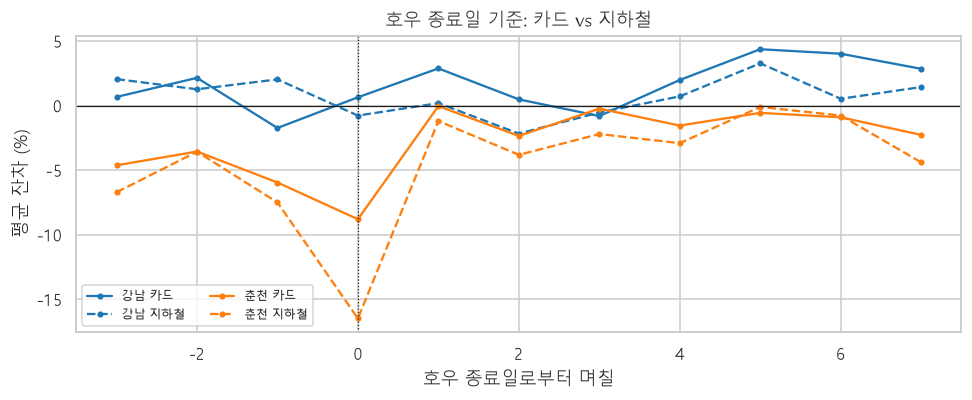

region              강남             춘천        
industry_group (지역 합계)  (지하철) (지역 합계)   (지하철)
k                                            
-3               0.700  2.000  -4.600  -6.700
-2               2.100  1.300  -3.600  -3.600
-1              -1.700  2.000  -6.000  -7.500
 0               0.600 -0.800  -8.800 -16.500
 1               2.900  0.200  -0.000  -1.200
 2               0.500 -2.200  -2.400  -3.800
 3              -0.800 -0.500  -0.200  -2.200
 4               2.000  0.700  -1.600  -2.900
 5               4.400  3.300  -0.600  -0.100
 6               4.000  0.500  -0.900  -0.800
 7               2.800  1.400  -2.300  -4.400

-> 춘천은 비 오는 날 유동이 먼저, 더 크게 빠지고 매출은 그 절반쯤 빠진다. 둘 다 다음 날 거의 돌아온다.
-> 강남은 비가 와도 지하철, 매출 모두 그대로다 (출퇴근 도시).
-> 춘천역은 이용객이 하루 약 1.2만 명으로 적어서 기준선 R2가 낮다. 값이 더 흔들린다는 뜻이다.


In [34]:
# 1) 지하철 표를 분석 기간으로 자르고 달력, 날씨 붙이기
sub = subway_daily[subway_daily['date'].isin(DAYS)].merge(calendar, on='date').merge(wx, on=['date', 'region'])
sub['y'] = np.log(sub['total'])
sub['normal'] = ~(sub['heat33'] | sub['rain30'])
print(f'sub {len(sub):,}행  ({sub["date"].min():%Y-%m-%d} ~ {sub["date"].max():%Y-%m-%d})')
display(sub.groupby('region')['total'].mean().round(0).rename('하루 평균 승하차').to_frame().T)

# 2) 6-4와 똑같이 평상일로만 기준선 학습 -> 잔차 -> resid_ev에 '(지하철)'로 추가
행 = []
for r in REGIONS:
    q = sub[sub['region'].eq(r)].copy()
    m = smf.ols('y ~ ' + CAL_FORMULA, data=q[q['normal']]).fit()
    print(f'{r} 지하철 평상일 기준선 R2 {m.rsquared:.3f}')
    q['resid'] = q['y'] - m.predict(q)
    q['industry_group'] = '(지하철)'
    행.append(q[['date', 'region', 'industry_group', 'resid', 'normal', 'heat33', 'rain30']])
resid_ev = pd.concat([resid_ev] + 행, ignore_index=True)

# 3) 3-3처럼 지하철에 달력 + 날씨 회귀
행 = []
for r in REGIONS:
    t = 효과표(날씨회귀(sub[sub['region'].eq(r)], cov='HC1'))
    t.insert(0, '지역', r)
    행.append(t)
지하철효과 = pd.concat(행, ignore_index=True)
지하철효과['날씨'] = 지하철효과['var'].map(WX_NAME)
display(지하철효과.pivot(index='날씨', columns='지역', values='eff').round(1).rename_axis('지하철 효과 (%)'))
display(지하철효과.pivot(index='날씨', columns='지역', values='p').round(3).rename_axis('p값'))
print('카드(3-3 지역 합계)와 비교')
display(effects_full[effects_full['group'].eq('(지역 합계)')]
        .pivot(index='var', columns='region', values='eff').round(1).rename_axis('카드 효과 (%)'))

# 4) 호우 궤적에 지하철을 겹쳐 그리기 (카드 = 실선, 지하철 = 점선)
for 기준, 이름 in [('start', '시작일'), ('end', '종료일')]:
    t = 궤적요약(궤적표('rain30', 기준=기준))
    fig, ax = plt.subplots(figsize=(9, 3.8))
    for r in REGIONS:
        for g, ls in [('(지역 합계)', '-'), ('(지하철)', '--')]:
            s = t[t['region'].eq(r) & t['industry_group'].eq(g)].sort_values('k')
            ax.plot(s['k'], s['mean'], ls, color=REGION_COLOR[r], marker='o', ms=3,
                    label=f'{r} {"카드" if g == "(지역 합계)" else "지하철"}')
    ax.axhline(0, color='k', lw=0.8); ax.axvline(0, ls=':', color='k', lw=0.8)
    ax.set(xlabel=f'호우 {이름}로부터 며칠', ylabel='평균 잔차 (%)', title=f'호우 {이름} 기준: 카드 vs 지하철')
    ax.legend(fontsize=8, ncol=2)
    plt.tight_layout(); plt.show()
    display(t[t['industry_group'].isin(['(지역 합계)', '(지하철)'])]
            .pivot(index='k', columns=['region', 'industry_group'], values='mean').round(1))

print('-> 춘천은 비 오는 날 유동이 먼저, 더 크게 빠지고 매출은 그 절반쯤 빠진다. 둘 다 다음 날 거의 돌아온다.')
print('-> 강남은 비가 와도 지하철, 매출 모두 그대로다 (출퇴근 도시).')
print('-> 춘천역은 이용객이 하루 약 1.2만 명으로 적어서 기준선 R2가 낮다. 값이 더 흔들린다는 뜻이다.')

### 8장 정리
- **본 것**: 업종그룹마다 회복 유형을 한 단어로 붙이고, 지하철 승하차 궤적을 카드 궤적 위에 겹쳤다.
- **나온 것**: 춘천 호우만 충격이 잡힌다 - 즉시회복 10, 지연회복 3(생활/취미용품, 숙박/여행, 패션/뷰티), 미회복 1(여가/오락). 강남은 호우, 폭염 모두 "충격 없음"이 12 ~ 13개다.
  지하철은 춘천 호우일 -15.8%로 **카드(-8.7%)의 약 2배** 빠지고, 궤적도 k=0 -15.3% -> k=+1 -3.6%로 같은 모양이다. 강남은 지하철도 카드도 +0.3%, -0.6%로 그대로다.
- **시사점**: 춘천은 **유동이 먼저 크게 빠지고 매출이 그 절반쯤 따라 빠지는** 구조다. 강남은 출퇴근 수요가 날씨를 막아 준다. 두 지역의 차이는 크기가 아니라 메커니즘의 차이다.
  [추론] 춘천역 기준선 R²가 0.681로 낮은 것(하루 약 1.2만 명)은 표본이 작아서로 보이지만, 역 하나가 춘천시 전체 유동을 대표한다는 가정 자체도 검증되지 않았다.

## 9. 전체 정리

### 9-1. 핵심 결과표와 두 지역 비교

열,구분,강남 폭염,춘천 폭염,강남 호우,춘천 호우
업종그룹,,,,,
(지역 합계),합계,+2.7,+1.7,-0.6,-8.7*
교통/차량,,+2.9,+0.1,-2.4,-11.5*
대형유통,,+8.4*,+22.4*,-1.6,-22.4*
미용/생활서비스,,+1.0,+3.5,+1.0,-5.6*
생활/취미용품,,+2.3,+11.5*,-0.8,-7.6
숙박/여행,,+8.8,+18.2,+4.2,-11.6
스포츠시설,,+0.7,-4.9,-1.2,-34.6*
식료품,1순위,+1.1,-2.4,-5.4,-7.5*
여가/오락,주의,-0.3,+7.3,-1.7,-11.5*


폭염: 두 지역 같은 부호 9/14개, 상관계수 0.74  (음수인 업종그룹 강남 3개, 춘천 4개)
호우: 두 지역 같은 부호 9/14개, 상관계수 0.20  (음수인 업종그룹 강남 9개, 춘천 14개)


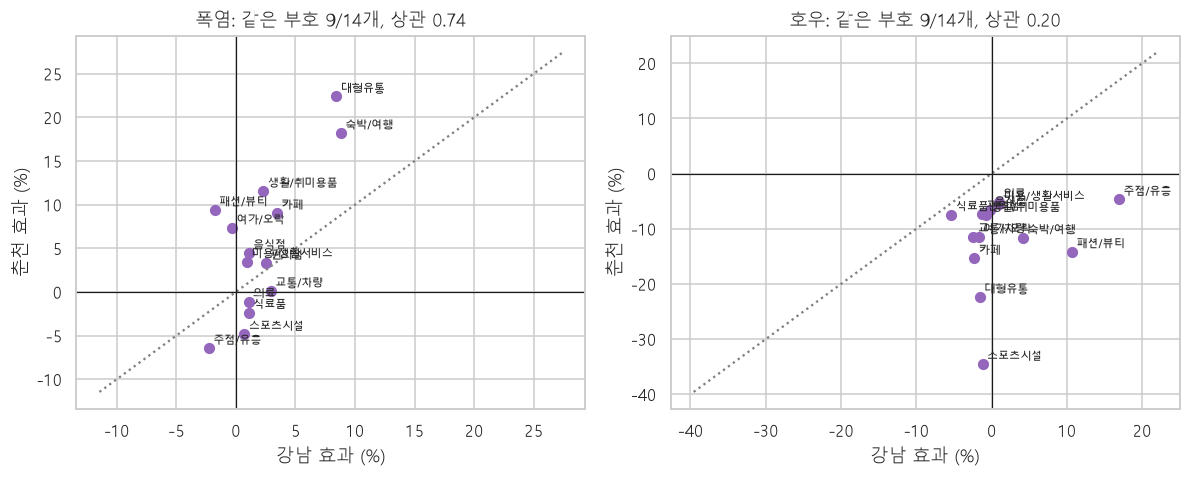

-> 폭염 효과는 두 지역이 같은 모양(카페, 편의점, 대형유통이 +)으로 복제된다.
-> 호우는 춘천에서만 뚜렷하다. 부호는 같아도 강남 쪽 크기가 거의 0이다.


In [35]:
# 1) 3-3의 효과 표를 보고서용으로 다듬기 (* = 95% 신뢰구간이 0을 안 걸침)
핵심 = effects_full[effects_full['var'].ne('tropical')].copy()
핵심['표시'] = [f'{e:+.1f}' + ('*' if s else '') for e, s in zip(핵심['eff'], 핵심['유의'])]
핵심['열'] = 핵심['region'] + ' ' + 핵심['var'].map(WX_NAME)
결과표 = 핵심.pivot(index='group', columns='열', values='표시')
결과표 = 결과표[['강남 폭염', '춘천 폭염', '강남 호우', '춘천 호우']]
결과표 = 결과표.reindex(['(지역 합계)'] + GROUPS)
결과표.insert(0, '구분', ['합계'] + ['1순위' if g in PRIORITY_GROUPS else
                                   ('주의' if g in CAUTION_GROUPS else '') for g in GROUPS])
display(결과표.rename_axis('업종그룹'))

# 2) 두 지역 비교 산점도 (업종그룹 14개)
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, v in zip(axes, ['heat33', 'rain30']):
    t = (effects_full[effects_full['var'].eq(v) & effects_full['group'].ne('(지역 합계)')]
         .pivot(index='group', columns='region', values='eff'))
    ax.scatter(t['강남'], t['춘천'], s=40, color='tab:purple')
    for g, x in t.iterrows():
        ax.annotate(g, (x['강남'], x['춘천']), fontsize=7, xytext=(3, 3), textcoords='offset points')
    lim = [min(t.min()) - 5, max(t.max()) + 5]
    ax.plot(lim, lim, ls=':', color='0.5')
    ax.axhline(0, color='k', lw=0.8); ax.axvline(0, color='k', lw=0.8)
    같은부호 = int((np.sign(t['강남']) == np.sign(t['춘천'])).sum())
    상관 = t['강남'].corr(t['춘천'])
    ax.set(xlabel='강남 효과 (%)', ylabel='춘천 효과 (%)',
           title=f'{WX_NAME[v]}: 같은 부호 {같은부호}/{len(t)}개, 상관 {상관:.2f}')
    print(f'{WX_NAME[v]}: 두 지역 같은 부호 {같은부호}/{len(t)}개, 상관계수 {상관:.2f}'
          f'  (음수인 업종그룹 강남 {(t["강남"] < 0).sum()}개, 춘천 {(t["춘천"] < 0).sum()}개)')
plt.tight_layout(); plt.show()
print('-> 폭염 효과는 두 지역이 같은 모양(카페, 편의점, 대형유통이 +)으로 복제된다.')
print('-> 호우는 춘천에서만 뚜렷하다. 부호는 같아도 강남 쪽 크기가 거의 0이다.')

### 9-2. 회복 유형 표

In [36]:
최종 = 그룹만.copy()
최종['충격(%)'] = (최종['during'] * 100).round(1)
최종['종료 후 1주(%)'] = (최종['post1_7'] * 100).round(1)
최종['회복 유형'] = 최종['유형'] + np.where(최종['반등'], ' +반등', '')

for 이름 in ['폭염', '호우']:
    t = 최종[최종['이벤트'].eq(이름)]
    표 = t.pivot(index='industry_group', columns='region',
                values=['충격(%)', '회복 유형', '종료 후 1주(%)'])
    표 = 표.swaplevel(axis=1)[[(r, c) for r in REGIONS
                              for c in ['충격(%)', '회복 유형', '종료 후 1주(%)']]]
    표 = 표.reindex(GROUPS)
    표.insert(0, ('구분', ''), ['1순위' if g in PRIORITY_GROUPS else
                              ('주의' if g in CAUTION_GROUPS else '') for g in GROUPS])
    print(f'{이름} (충격 = 이벤트 중 평균 잔차, 종료 후 1주 = 끝난 뒤 1 ~ 7일 평균 잔차)')
    display(표.rename_axis('업종그룹'))

print('-> 1순위 = 규모가 크고 안정적이라 결과를 믿을 수 있는 그룹 (02번 5-4).')
print('-> 주의 = 결제가 0건인 날이 잦아 조심해서 읽을 그룹 (02번 2-3).')

폭염 (충격 = 이벤트 중 평균 잔차, 종료 후 1주 = 끝난 뒤 1 ~ 7일 평균 잔차)


region     구분     강남                        춘천                  
               충격(%)  회복 유형 종료 후 1주(%)   충격(%)  회복 유형 종료 후 1주(%)
업종그룹                                                            
교통/차량          4.900  충격 없음      0.600  -3.900   즉시회복     -3.800
대형유통           5.800  충격 없음     -0.900  25.300  충격 없음      0.700
미용/생활서비스      -0.500  충격 없음     -1.100  -0.000  충격 없음     -2.900
생활/취미용품        2.300  충격 없음     -1.400  10.500  충격 없음     -0.500
숙박/여행          3.100  충격 없음      1.800  -0.300  충격 없음     -7.500
스포츠시설          3.000  충격 없음      0.200  -4.900    미회복     -9.600
식료품       1순위 -0.700  충격 없음     -2.400  -2.700  충격 없음     -3.400
여가/오락      주의 -0.000  충격 없음     -2.600  14.600  충격 없음     -0.100
음식점       1순위  0.900  충격 없음      0.600   1.800  충격 없음     -1.700
의료            -7.400   즉시회복     -4.300   2.100  충격 없음     -0.500
주점/유흥      주의  3.000  충격 없음     -1.500 -14.500    미회복     -6.800
카페        1순위  3.500  충격 없음     -1.100   6.100  충격 없음     -2.800
패션/뷰티          1.800  충격 없음      1.700  -2.800  충격 없음     -6.800
편의점       1순위  2.400  충격 없음      0.200  -0.100  충격 없음     -1.700

호우 (충격 = 이벤트 중 평균 잔차, 종료 후 1주 = 끝난 뒤 1 ~ 7일 평균 잔차)


region     구분     강남                            춘천                 
               충격(%)      회복 유형 종료 후 1주(%)   충격(%) 회복 유형 종료 후 1주(%)
업종그룹                                                               
교통/차량         -2.200      충격 없음     -0.300 -11.000  즉시회복     -1.900
대형유통           1.200      충격 없음      2.700 -21.800  즉시회복      2.800
미용/생활서비스       2.300      충격 없음      1.300  -5.700  즉시회복     -1.200
생활/취미용품       -1.700      충격 없음      0.900  -7.900  지연회복     -2.300
숙박/여행          4.800  충격 없음 +반등      4.800 -14.700  지연회복     -5.000
스포츠시설         -3.000       즉시회복     -1.000 -40.600  즉시회복     -5.500
식료품       1순위 -3.800       즉시회복      1.300  -7.000  즉시회복     -0.700
여가/오락      주의 -1.900      충격 없음      1.800 -14.900   미회복     -4.700
음식점       1순위 -0.100      충격 없음      0.100  -6.000  즉시회복     -0.900
의료             1.900  충격 없음 +반등      5.100  -6.700  즉시회복     -0.500
주점/유흥      주의 14.200      충격 없음      1.700  -7.000  즉시회복     -0.400
카페        1순위 -2.000      충격 없음      1.800 -16.300  즉시회복     -1.200
패션/뷰티          8.400      충격 없음     -2.900 -15.700  지연회복     -1.800
편의점       1순위 -1.000      충격 없음      0.900  -7.200  즉시회복     -0.100

-> 1순위 = 규모가 크고 안정적이라 결과를 믿을 수 있는 그룹 (02번 5-4).
-> 주의 = 결제가 0건인 날이 잦아 조심해서 읽을 그룹 (02번 2-3).


### 9-3. 결정 사항과 한계
보고서와 06번 해석에서 이 목록을 그대로 가져다 쓴다.

| 항목 | 결정 | 근거 (몇 장) |
|---|---|---|
| 달력 통제 식 (추석 3일 포함 여부) | 추석 전날, 당일, 다음날을 `C(chuseok_day)` 로 따로 통제. 추석 3일에 걸린 호우(강남 10/6)는 호우 효과에서 뺌. 월말 더미는 기본 식에 넣지 않고 두 값을 함께 보고 | 2-4 |
| 폭염 임계값 | 33℃ 유지. 데이터에 꺾이는 점이 없음 | 3-4, 07번 Q3 |
| 주제의 무게중심 (폭염 / 호우 / 둘 다) | **호우 중심.** 폭염은 "업종별 수요 이동"으로만 다룸 | 3-2, 3-3 |
| 결과를 믿을 수 있는 업종그룹 | 음식점, 카페, 편의점, 식료품 (+ 대형유통, 교통/차량). 평상일 잔차 표준편차 4 ~ 10% | 3-3, 6-4 |
| 조심해서 읽을 업종그룹 (0인 날이 잦은 그룹) | 주점/유흥, 여가/오락, 숙박/여행, 스포츠시설. 표준편차 15 ~ 39%라 방향만 읽음 | 3-3, 02번 2-3 |
| 이벤트 창과 폭염 이벤트 대안 | 창은 -3 ~ +7일. 폭염은 창 겹침을 인정하고 참고로만, 핵심은 7-5의 여름 끝 전환 한 번 | 6-2, 6-3 |
| 순손실인가 시점 이동인가 | **순손실.** 호우 종료 후 1주 평균이 춘천 -1.1%(p 0.47), 강남 +2.2%(p 0.37)로 반등이 없음 | 7-4 |
| 회복 유형 규칙과 RECOVERY_BAND | 0.03 유지. 충격 없음 -> 즉시회복 -> 지연회복 -> 미회복 순으로 판정 | 8-1 |
| 두 지역이 같은 방향인가 | 폭염은 같은 모양으로 복제됨(같은 부호 9/14, 상관 0.74). 호우는 부호만 같고 크기는 춘천에만 있음(상관 0.20) | 9-1 |

**한계**
- 폭염 구간이 2 ~ 3일 간격으로 붙어 있어 이벤트 창이 겹침 (-7 ~ +14일이 깨끗한 폭염 구간 0개)
- 시간대가 6시간 단위라 14 ~ 16시 폭염 피크가 12_17 안에 묻힘
- 날씨 효과는 월 더미 안에서만 잡힘 (여름 전체가 더운 효과는 월 효과와 구분 불가)
- 지역이 2개뿐이라 지역 차이는 검정이 아니라 "같은 방향인가"로만 말할 수 있음
- 월말 효과(약 10%p)가 날씨 효과보다 커서, 월말 통제 여부에 따라 폭염 계수가 1 ~ 2%p 움직임
- 금액이 0인 칸 504개는 로그를 쓸 수 없어 회귀에서 빠짐. 0이 잦은 업종은 그만큼 표본이 줄어듦
- 카드 데이터의 금액과 건수는 원자료가 아니라 배수가 곱해진 값이다 (08번). 비중과 변화율은 믿을 수 있지만 **절대 금액은 그대로 쓰면 안 됨**
- 지하철은 춘천역 1개, 강남 지역 역들로만 유동을 대표함. 춘천 기준선 R²가 0.681로 낮음

### 9-4. 더 확인할 것
06번이나 보고서에서 확인할 질문을 적어 둔다.
- 강남 30 ~ 33℃ 날만 매출이 낮은 이유 (3-4) -> 그 날들의 요일, 휴가철 분포 확인
- 춘천 폭염 뒤 1주일이 낮은 것(7-4)이 창 겹침 때문인지, 휴가철이 끝나서인지
- 춘천 호우일 외지인 감소(5-2)를 관광 통계(06번 관광-카드 외지인 상관 0.97)와 교차 확인
- `RECOVERY_BAND` 를 0.05로 넓혀 다시 돌렸을 때 춘천 호우의 지연회복 3개가 즉시회복으로 바뀌는지 (8-1 결정)
- 월말 더미를 넣은 식으로 전체를 한 번 더 돌려, 업종그룹 결과의 순서가 바뀌는 곳이 있는지 (2-4 결정)
- 춘천 대형유통이 폭염에 +22.4%인데 건수는 -5.8%인 이유 (5-1) -> 실제로 대형마트 한 번 방문에 더 많이 사는지, 특정 점포 효과인지
- [추론] 춘천 호우 때 고령층이 더 크게 빠지는 것(4-1)이 이동 수단 차이인지 확인할 외부 자료가 있는지